# single_grid — the whole evolution in ONE circuit, no state tomography

The enhanced algorithm as implemented in `circuit.ipynb` reads the state out after every step and feeds
it back in. That read-out is a **simulator convenience, not physics** — but as written it would need
state tomography on hardware, which is exactly what we want to avoid.

This notebook builds the propagation as **one continuous circuit**: load $\rho(0)$ at the start, run to
$t=T$ for any $T$, and never reconstruct or re-prepare the system in between.

Two routes, because the Markovian and the non-Markovian case are structurally different:

| | route | ancilla | measurement of the system | success prob. |
|---|---|---|---|---|
| **Lindblad** (CPTP) | **Stinespring**: unitary + discard the environment | env register, reset each step | **never** | **1** |
| **HEOM / path integral** (non-CP) | **Sz.-Nagy** on the Krylov-compressed operator | 1 qubit, measured each step | **never** | $\approx0.33$ |

**Why the two must differ — a structural fact.** A CPTP map applied over and over to the *system alone*
is a semigroup, i.e. Markovian by construction. So non-Markovian dynamics needs either a coherent memory
register (which contains bath in qubits -> expensive but CP) or non-CP (like $E(\Delta t)$) operations (= post-selection = measure the ancilla after every step. If it is $\ket{1}$ terminate). There is no third option. Lindblad is CPTP, so it gets
the deterministic route; the memory-enhanced operator $E$ is not, so it keeps one ancilla measurement per
step. Since $E(\Delta t)$ is not CP (since we cut off the bath) we must use Sz.-Nagy instead of stinespring.

**That ancilla measurement is not tomography.** It is a single-qubit read-out that never touches the
system/memory register, and the register is never re-prepared. Runs where the ancilla comes out
$|1\rangle$ are simply discarded. This is one continuous grid in the sense you asked for.

**On the intermediate states.** In the simulator, snapshots give $\rho(t)$ for *every* $t$ from a single
execution. On hardware that is impossible in one run — measuring at time $t$ collapses the state, so you
would run the same circuit once per target $T$ (each run still internally continuous, still no
tomography). The functions below take `n_steps`, so any $T=n\,\Delta t$ works.

---
# Theory

Everything below is derived from scratch. Every statement that is not a definition or an immediate
consequence of one is proved, and the proofs are written out rather than cited, so that each formula
that appears in the code can be traced back to its origin. Throughout, $\mathcal H\cong\mathbb C^{d}$ is
the $d$-site system space, $D=d^2$, and $\|\cdot\|_2$ denotes the operator (spectral) norm and
$\|\cdot\|$ the Euclidean vector norm.

## 1. Vectorisation, the dynamical map, and its operator-sum form

### 1.1 The column-stacking isomorphism

> **Lemma 1.** For all $A,B,X\in\mathbb C^{d\times d}$,
> $$\operatorname{vec}(AXB)=\big(B^{\mathsf T}\otimes A\big)\operatorname{vec}(X).$$

### 1.2 The map and its matrix

The reduced state obeys $\rho(t)=\Phi_t[\rho(0)]$ with $\Phi_t$ linear, so there is a matrix
$\mathcal L(t)\in\mathbb C^{D\times D}$ with
$$\operatorname{vec}\big(\rho(t)\big)=\mathcal L(t)\operatorname{vec}\big(\rho(0)\big),\qquad
\mathcal L(t)_{\,ab}=\Big[\operatorname{vec}\Phi_t\big(\operatorname{unvec}(e_b)\big)\Big]_a,$$
i.e. the $b$-th column of $\mathcal L$ is the image of the $b$-th matrix unit. This is precisely what
`main.ipynb` stores: $e^{Lt}$ for Lindblad, the zeroth-ADO block of $e^{\hat{\mathcal L}_{\rm HEOM}t}$
for HEOM, and the contracted influence functional for TEMPO.

Wir haben in $D=d^2=4$: $$e_1 = \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix}, \quad e_2 = \begin{pmatrix} 0 \\ 1 \\ 0 \\ 0 \end{pmatrix}, \quad e_3 = \begin{pmatrix} 0 \\ 0 \\ 1 \\ 0 \end{pmatrix}, \quad e_4 = \begin{pmatrix} 0 \\ 0 \\ 0 \\ 1 \end{pmatrix} \quad \operatorname{unvec}(e_3) = \begin{pmatrix} 0 & 1 \\ 0 & 0 \end{pmatrix}$$

Nehmen wir eine unbekannte $4 \times 4$ Matrix $\mathcal{L}$ und multiplizieren sie mit dem dritten Standardbasisvektor $e_3$:$$\mathcal{L} \cdot e_3 = \begin{pmatrix} \mathcal{L}_{11} & \mathcal{L}_{12} & \mathcal{L}_{13} & \mathcal{L}_{14} \\ \mathcal{L}_{21} & \mathcal{L}_{22} & \mathcal{L}_{23} & \mathcal{L}_{24} \\ \mathcal{L}_{31} & \mathcal{L}_{32} & \mathcal{L}_{33} & \mathcal{L}_{34} \\ \mathcal{L}_{41} & \mathcal{L}_{42} & \mathcal{L}_{43} & \mathcal{L}_{44} \end{pmatrix} \begin{pmatrix} 0 \\ 0 \\ 1 \\ 0 \end{pmatrix} = \begin{pmatrix} \mathcal{L}_{13} \\ \mathcal{L}_{23} \\ \mathcal{L}_{33} \\ \mathcal{L}_{43} \end{pmatrix}$$

Das Ergebnis ist exakt die 3. Spalte von $\mathcal{L}$. Allgemein gilt für jeden Basisvektor $e_b$:$$\mathcal{L} \cdot e_b = \text{die } b\text{-te Spalte von } \mathcal{L}$$

Laut deiner Definition ist $\mathcal{L}(t)$ genau die Matrix-Darstellung der linearen physikalischen Abbildung $\Phi_t$ im vektorisierten Raum. Das bedeutet, das Verhalten von $\mathcal{L}$ auf einen Vektor ist exakt definiert als das Verhalten von $\Phi_t$ auf die entsprechende Matrix:$$\mathcal{L}(t) \cdot \operatorname{vec}(\rho) \equiv \operatorname{vec}\big( \Phi_t[\rho] \big) = \rho(t)$$

Setzen wir also spezifisch $\operatorname{vec}(\rho) = e_b$ (bzw. $\rho = \operatorname{unvec}(e_b) = E_{ij}$) in diese Gleichung ein:$$\underbrace{\mathcal{L}(t) \cdot e_b}_{\text{Die } b\text{-te Spalte von } \mathcal{L}(t)} = \operatorname{vec}\Big( \Phi_t\big[\operatorname{unvec}(e_b)\big] \Big)$$

Deine Dichtematrix ist eine Linearkombination aus diesen Matrixeinheiten. Wenn du ein Qubit hast, kannst du jede Dichtematrix schreiben als:$$\rho = \rho_{11} E_{11} + \rho_{12} E_{12} + \rho_{21} E_{21} + \rho_{22} E_{22}$$Da die Zeitentwicklung $\Phi_t$ linear ist (Superpositionsprinzip), gilt:$$\Phi_t[\rho] = \rho_{11} \Phi_t[E_{11}] + \rho_{12} \Phi_t[E_{12}] + \rho_{21} \Phi_t[E_{21}] + \rho_{22} \Phi_t[E_{22}]$$Wenn du die Evolution für die vier elementaren Bausteine $\Phi_t[E_{ij}]$ einmal berechnet und als Spalten in $\mathcal{L}(t)$ abgespeichert hast, musst du für keinen zukünftigen Anfangszustand $\rho(0)$ jemals wieder eine aufwendige Differentialgleichung (wie HEOM oder TEMPO) lösen!Du nimmst einfach deinen neuen Anfangszustand, wirfst ihn in die Vektorform und machst eine simple, extrem schnelle Matrix-Vektor-Multiplikation:$$\operatorname{vec}\big(\rho(t)\big) = \mathcal{L}(t) \cdot \operatorname{vec}\big(\rho(0)\big)$$

### Krausoperatoren aus der Choi-Matrix
Wir zeigen zuerst dass folgendes gilt:
$$\sum_{i,j=1}^N (E_{ij} \otimes I) \mathcal{L}(t) (I \otimes E_{ij}) = \sum_{i,j=1}^N E_{ij} \otimes \Phi_t(E_{ij})$$

Dazu definieren wir die folgenden Objekte:

- $\mathcal{L} = \begin{pmatrix} a & b & c & d \\ e & f & g & h \\ i & j & k & l \\ m & n & o & p \end{pmatrix}$
- $\operatorname{vec}(E_{11}) = (1, 0, 0, 0)^T \implies \mathcal{L} \cdot \operatorname{vec}(E_{11}) = (a, e, i, m)^T$
- $\operatorname{vec}(E_{21}) = (0, 1, 0, 0)^T \implies \mathcal{L} \cdot \operatorname{vec}(E_{21}) = (b, f, j, n)^T$
- $\operatorname{vec}(E_{12}) = (0, 0, 1, 0)^T \implies \mathcal{L} \cdot \operatorname{vec}(E_{12}) = (c, g, k, o)^T$
- $\operatorname{vec}(E_{22}) = (0, 0, 0, 1)^T \implies \mathcal{L} \cdot \operatorname{vec}(E_{22}) = (d, h, l, p)^T$


**LHS: $\sum_{i,j=1}^N (E_{ij} \otimes I) \mathcal{L}(t) (I \otimes E_{ij})$**:

- $$(E_{11} \otimes I) \cdot \mathcal{L} \cdot (I \otimes E_{11}) = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix} \begin{pmatrix} a & b & c & d \\ e & f & g & h \\ i & j & k & l \\ m & n & o & p \end{pmatrix} \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix} = \begin{pmatrix} a & 0 & c & 0 \\ e & 0 & g & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix}$$

- $$(E_{12} \otimes I) \cdot \mathcal{L} \cdot (I \otimes E_{12}) = \begin{pmatrix} 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix} \begin{pmatrix} a & b & c & d \\ e & f & g & h \\ i & j & k & l \\ m & n & o & p \end{pmatrix} \begin{pmatrix} 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 \end{pmatrix} = \begin{pmatrix} 0 & i & 0 & k \\ 0 & m & 0 & o \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix}$$

- $$(E_{21} \otimes I) \cdot \mathcal{L} \cdot (I \otimes E_{21}) = \begin{pmatrix} 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{pmatrix} \begin{pmatrix} a & b & c & d \\ e & f & g & h \\ i & j & k & l \\ m & n & o & p \end{pmatrix} \begin{pmatrix} 0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \end{pmatrix} = \begin{pmatrix} 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ b & 0 & d & 0 \\ f & 0 & h & 0 \end{pmatrix}$$

- $$(E_{22} \otimes I) \cdot \mathcal{L} \cdot (I \otimes E_{22}) = \begin{pmatrix} 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix} \begin{pmatrix} a & b & c & d \\ e & f & g & h \\ i & j & k & l \\ m & n & o & p \end{pmatrix} \begin{pmatrix} 0 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix} = \begin{pmatrix} 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & j & 0 & l \\ 0 & n & 0 & p \end{pmatrix}$$

$${\text{LHS}} = \begin{pmatrix} a & 0 & c & 0 \\ e & 0 & g & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix} + \begin{pmatrix} 0 & i & 0 & k \\ 0 & m & 0 & o \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix} + \begin{pmatrix} 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ b & 0 & d & 0 \\ f & 0 & h & 0 \end{pmatrix} + \begin{pmatrix} 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & j & 0 & l \\ 0 & n & 0 & p \end{pmatrix} = \begin{pmatrix} a & i & c & k \\ e & m & g & o \\ b & j & d & l \\ f & n & h & p \end{pmatrix}$$

**RHS**:
$$\Phi(E_{11}) = \begin{pmatrix} a & i \\ e & m \end{pmatrix}, \quad \Phi(E_{21}) = \begin{pmatrix} b & j \\ f & n \end{pmatrix}, \quad \Phi(E_{12}) = \begin{pmatrix} c & k \\ g & o \end{pmatrix}, \quad \Phi(E_{22}) = \begin{pmatrix} d & l \\ h & p \end{pmatrix}$$
 
$$\text{RHS} = \sum_{i,j=1}^N E_{ij} \otimes \Phi_t(E_{ij}) = \begin{pmatrix} \Phi(E_{11}) & \Phi(E_{12}) \\ \Phi(E_{21}) & \Phi(E_{22}) \end{pmatrix} = \begin{pmatrix} a & i & c & k \\ e & m & g & o \\ b & j & d & l \\ f & n & h & p \end{pmatrix}$$



**Herleitung der Krausoperatoren aus der CHoi Matrix:**

Wir starten mit der Definition der Choi-Matrix für eine komplett positive (CP) Abbildung $\Phi$. Für ein $2 \times 2$ System ($d=2$) ist $C(\Phi)$ eine $4 \times 4$ Matrix. Wir füllen die Blöcke mit beispielhaften Einträgen $c_{xy}$:$$C(\Phi) = \sum_{i,j=1}^2 E_{ij} \otimes \Phi(E_{ij}) = \begin{pmatrix} \Phi(E_{11}) & \Phi(E_{12}) \\ \Phi(E_{21}) & \Phi(E_{22}) \end{pmatrix} = \begin{pmatrix} c_{11} & c_{12} & c_{13} & c_{14} \\ c_{21} & c_{22} & c_{23} & c_{24} \\ c_{31} & c_{32} & c_{33} & c_{34} \\ c_{41} & c_{42} & c_{43} & c_{44} \end{pmatrix}$$Da die Abbildung $\Phi$ CP ist, wissen wir, dass die große $4 \times 4$ Matrix $C(\Phi)$ positiv semidefinit ist. Das bedeutet, wir können sie diagonalisieren (Spektralzerlegung) und sie hat nur nicht-negative Eigenwerte $\sigma_k \ge 0$. Mit den Vektoren $v_k := \sqrt{\sigma_k} u_k$ (denen wir die Einträge $a_k, b_k, c_k, d_k$ geben) sieht das äußere Produkt so aus:$$v_k = \begin{pmatrix} a_k \\ b_k \\ c_k \\ d_k \end{pmatrix} \quad \implies \quad v_k v_k^\dagger = \begin{pmatrix} a_k \\ b_k \\ c_k \\ d_k \end{pmatrix} \begin{pmatrix} \overline{a_k} & \overline{b_k} & \overline{c_k} & \overline{d_k} \end{pmatrix} = \begin{pmatrix} \vert{}a_k\vert{}^2 & a_k\overline{b_k} & a_k\overline{c_k} & a_k\overline{d_k} \\ b_k\overline{a_k} & \vert{}b_k\vert{}^2 & b_k\overline{c_k} & b_k\overline{d_k} \\ c_k\overline{a_k} & c_k\overline{b_k} & \vert{}c_k\vert{}^2 & c_k\overline{d_k} \\ d_k\overline{a_k} & d_k\overline{b_k} & d_k\overline{c_k} & \vert{}d_k\vert{}^2 \end{pmatrix}$$Die Spektralzerlegung der Choi-Matrix lautet dann:$$C(\Phi) = \sum_k \sigma_k u_k u_k^\dagger = \sum_k v_k v_k^\dagger = \sum_k \begin{pmatrix} \vert{}a_k\vert{}^2 & a_k\overline{b_k} & a_k\overline{c_k} & a_k\overline{d_k} \\ b_k\overline{a_k} & \vert{}b_k\vert{}^2 & b_k\overline{c_k} & b_k\overline{d_k} \\ c_k\overline{a_k} & c_k\overline{b_k} & \vert{}c_k\vert{}^2 & c_k\overline{d_k} \\ d_k\overline{a_k} & d_k\overline{b_k} & d_k\overline{c_k} & \vert{}d_k\vert{}^2 \end{pmatrix}$$Jeder Vektor $v_k$ hat die Länge $d^2 = 4$. Wir können diesen langen Vektor in eine quadratische $2 \times 2$ Matrix umformen (das ist das $\operatorname{unvec}$). Nennen wir diese Matrix $M_k$.Die mathematische Regel dafür (wie im Skript) lautet, dass der Eintrag an der Stelle $(i, a)$ des Vektors zum Matrixeintrag $(M_k)_{ai}$ wird. Wir ordnen also die Einträge $a_k, b_k, c_k, d_k$ (welche den Doppel-Indizes $(1,1), (1,2), (2,1), (2,2)$ entsprechen) entsprechend um:$$M_k = \begin{pmatrix} (M_k)_{11} & (M_k)_{12} \\ (M_k)_{21} & (M_k)_{22} \end{pmatrix} = \begin{pmatrix} (v_k)_{(1,1)} & (v_k)_{(2,1)} \\ (v_k)_{(1,2)} & (v_k)_{(2,2)} \end{pmatrix} = \begin{pmatrix} a_k & c_k \\ b_k & d_k \end{pmatrix}$$Wir schauen uns nun einen ganz bestimmten Eintrag der Matrix $C(\Phi)$ an, um zu prüfen, ob die Rechnung aufgeht: Nehmen wir den Block $(i=1, j=2)$ und darin das Element $(a=2, b=1)$.Laut der Definition der Choi-Matrix (unsere Startgleichung) steht genau dort der Eintrag der abgebildeten Matrixeinheit $\Phi(E_{12})$. In unserer großen Matrix ist das exakt der Eintrag in Zeile 2, Spalte 3 (also $c_{23}$):$$C_{(1,2),(2,1)} = \big[\Phi(E_{12})\big]_{21} = c_{23}$$Wenn wir stattdessen unsere Spektralzerlegung ($v_k v_k^\dagger$) anschauen und genau diesen Eintrag (Zeile 2, Spalte 3) in der symbolischen Matrix ablesen, erhalten wir:$$C_{(1,2),(2,1)} = \sum_k (v_k)_{(1,2)} \overline{(v_k)_{(2,1)}} = \sum_k b_k \overline{c_k}$$Wenn wir das nun mit unserer neuen Matrix $M_k = \begin{pmatrix} a_k & c_k \\ b_k & d_k \end{pmatrix}$ schreiben, bei der $(M_k)_{21} = b_k$ und $(M_k^\dagger)_{12} = \overline{c_k}$ gilt, ergibt sich:$$= \sum_k (M_k)_{21} (M_k^\dagger)_{12} = \sum_k b_k \overline{c_k}$$Das Produkt $(M_k)_{ai} (M_k^\dagger)_{jb}$ ist nach den Regeln der Matrixmultiplikation exakt das Matrixelement $\big[M_k E_{ij} M_k^\dagger\big]_{ab}$.Wir haben soeben gezeigt, dass für jede elementare Basis-Matrix $E_{ij}$ gilt:
$$C_{(i,a),(j,b)} = [\Phi(E_{ij})]_{a,b} = \Big [\sum_k M_k E_{ij} M_k^\dagger \Big ]_{a,b}$$
Da jede beliebige Dichtematrix $\rho$ nur eine Linearkombination dieser $E_{ij}$ ist, gilt die Gleichung für alle $\rho$. Wir haben die Kraus-Zerlegung gefunden!


Man kann auch zeigen dass $\Phi$ nur Spurerhaltend ist, wenn $\sum_kM_k^\dagger M_k=\mathbb 1$.
Dazu verwenden wir die zyklische property: $\operatorname{Tr}\Phi(\rho)=\sum_k\operatorname{Tr}(M_k\rho M_k^\dagger) =\operatorname{Tr}\big[(\sum_kM_k^\dagger M_k)\rho\big] = \operatorname{Tr}[\mathbb 1\rho]= \operatorname{Tr}[\rho]$ wenn $\sum_kM_k^\dagger M_k=1$.

Die Choi-Zerlegung ist zwar der universellste numerische und algorithmische Weg, um Kraus-Operatoren aus einer Black-Box-Abbildung zu gewinnen, aber sie ist definitiv nicht die einzige Möglichkeit. Man z.B. Kraus Operatoren direkt aus der Lindblad-Gleichung finden:
- $M_0 = \mathbb{1} - \left( iH + \frac{1}{2} \sum_k L_k^\dagger L_k \right) \Delta t$
- $M_k = L_k \sqrt{\Delta t}$

### Warum Krausoperatoren
das Choi-Theorem beweist: Die Kraus-Struktur ist mathematisch die einzige Möglichkeit, offene Quantendynamik mit $d \times d$ CPTP Operatoren zu beschreiben. Es gibt schlichtweg keine andere algebraische Struktur, die eine Dichtematrix $\rho$ (Dimension $d \times d$) nimmt, sie so transformiert, dass sie physikalisch gültig bleibt (positive Eigenwerte behält), und dabei Operatoren der Dimension $d \times d$ verwendet. Wir können das an der allgemeinen Herleitung der Krausoperatoren sehen:

Für jedes erdenkliche offene Quantensystem (markovian und non-markovian)
- dessen gesamte Dynamik vom System und bad unitär ist
- bei dem die Umgebung augetraced wird, sodass nur Systemoperatoren übrig bleiben -> wirkt nur auf das System
- das mit seiner Umgebung wechselwirkt und in $\rho(0) = \rho_S(0) \otimes \rho_B$ startet wobei $\rho_S(0)$ und $\rho_B(0)$ gültige Dichtematrizen sind (-> positive Eigenwerte (=positive definit))

kann man die Dynamik ganz allgemein durch folgende Systemoperatoren beschreiben:

$$\begin{aligned}\rho_S(t) &= \operatorname{Tr}_B\big[ U(t) \rho(0) U^\dagger(t) \big] = \sum_\mu \langle \mu \vert{} U(t) \rho(0) U^\dagger(t) \vert{} \mu \rangle \\ &= \sum_\mu \langle \mu \vert{} U(t) \left( \rho_S(0) \otimes \sum_\nu \lambda_\nu \vert{} \nu \rangle \langle \nu \vert{} \right) U^\dagger(t) \vert{} \mu \rangle = \sum_{\mu\nu} \lambda_\nu \langle \mu \vert{} U(t) \vert{} \nu \rangle \rho_S(0) \langle \nu \vert{} U^\dagger(t) \vert{} \mu \rangle \end{aligned}$$

Weil $\lambda_\nu \ge 0$ ist (da die $\lambda_\nu$ als Eigenwerte von $\rho_B \geq 0$ da $\rho_B$ eine valide Dichtematrix sein muss), können wir problemlos die reale Wurzel $\sqrt{\lambda_\nu}$ ziehen. Somit fassen nun diesen gesamten Vorfaktor als einen neuen System-Operator zusammen:

$$M_{\mu\nu}(t) = \sqrt{\lambda_\nu} \langle \mu \vert{} U(t) \vert{} \nu \rangle$$
Hierbei wirkt $U$ auf das gesamte globale System und ist daher unitär. Wir erhalten also: 
$$\rho_S(t) = \sum_{\mu\nu} M_{\mu\nu}(t) \rho_S(0) M_{\mu\nu}^\dagger(t)$$

Für die oben genannten 3 Punkte ist das die einzige Lösung. Die Systemoperatoren die man erhält sind ganz allgemein und man nennt sie Krausoperatoren. Welche konkreten Kraus-Operatoren du wählst, ist nicht eindeutig. Du kannst die Kraus-Operatoren $M_k$ mit einer unitären Matrix $V$ durchmischen (z. B. $N_i = \sum_j V_{ij} M_j$). Die neuen Operatoren $N_i$ beschreiben physikalisch exakt dieselbe Dynamik $\Phi(\rho)$. 

### Halbgruppe, CP und positive definitness

In der Physik und Mathematik beschreibt eine (dynamische) Halbgruppe eine zeitliche Entwicklung, die kein Gedächtnis hat.Mathematisch definiert sich eine Halbgruppe durch die Eigenschaft:$$\Phi_{t+s} = \Phi_t \circ \Phi_s$$
Durch die Potenzgesetze der Exponentialfunktion sieht das so aus:$$\mathcal{L}(t+s) = e^{L(t+s)} = e^{Lt} \cdot e^{Ls} = \mathcal{L}(t) \cdot \mathcal{L}(s)$$Wendet man diese Eigenschaft nun $n$-mal für ein festes Zeitintervall $t$ (oder $\Delta t$) an, folgt daraus sofort die Potenzregel für diskrete Zeitschritte:$$\mathcal{L}(n \cdot t) = \big(\mathcal{L}(t)\big)^n$$

Das bedeutet: Ob du den Zustand in einem Rutsch um die Zeit $t+s$ in die Zukunft entwickelst, oder erst um $s$ und von dort aus nochmal um $t$, liefert exakt dasselbe Ergebnis.Physikalisch ist das die Markov-Näherung: Die Zukunft des Systems hängt nur vom jetzigen Zustand ab (das Bad vergisst alles sofort -> keine Einflüsse von alten Zuständen/Vorgeschichte), nicht davon, wie das System in diesen Zustand gekommen ist.

Deshalb scheitert die Halbgruppen-Logik bei HEOM auf dem reduzierten System und HEOM ist Keine Halbgruppe. Wegen des Gedächtnisses gilt für das System allein $\Phi_{t+s} \neq \Phi_t \circ \Phi_s$. Der Zustand des Systems bei $t$ reicht nicht aus, um die Zukunft vorherzusagen – du müsstest auch den Zustand der ADOs kennen. Zusammenfassend gilt:

$$\begin{aligned} \Phi \text{ ist eine Halbgruppe} \implies \Phi \text{ ist completely positive (CP)} &\iff C(\Phi) \text{ ist positiv semidefinit } (C(\Phi) \succeq 0) \\ \iff \Phi \text{ hat eine Kraus-Zerlegung} \end{aligned}$$

Wenn $\Phi$ keine Halbgruppe ist (der Prozess also ein Gedächtnis hat und nicht-Markovsch ist), können die drei Bedingungen auf der rechten Seite trotzdem erfüllt sein! HEOM / TEMPO: Sind keine Halbgruppen (die Umgebung hat ein Gedächtnis, $\Phi_{t+s} \neq \Phi_t \circ \Phi_s$). Trotzdem beschreiben sie eine physikalisch gültige Zeitentwicklung. Der Zustand zur Zeit $t$ hat niemals negative Wahrscheinlichkeiten.

Daraus folgt für HEOM und TEMPO:
- $\Phi_t$ ist CP. (Sonst könnte die map ein $\rho$ mit negativen Eigenwerten = Diag = populations erzeugen)
- Die Choi-Matrix $C(\Phi_t)$ ist positiv semidefinit.
- Du kannst für jeden Zeitpunkt $t$ eine Kraus-Zerlegung berechnen.

Der entscheidende Punkt ist, dass man mit dem HEOM-Propagator keine Zeitentwicklung der Form $\Phi_{t+s} = \Phi_t \circ \Phi_s$ machen kann, da der nächste Zustand nicht nur vom aktuellen abhängt. Daher muss ein Objekt als Propagator nehmen dass ein Gedächnis hat. Z.B die Zustände von den letzten 25 zeitschritten. Dann gilt Näherungsweise $\Phi_{t+s} \approx \Phi_t \circ \Phi_s$ und man kann dasselbe memory-objekt immerwieder anwenden.

GKLS-Theorem: Wenn eine Dynamik eine Halbgruppe ist (sich also als $\Phi_t = e^{Lt}$ mit einem zeitunabhängigen Generator $L$ schreiben lässt) UND completely positive (CP) sowie spurerhaltend (TP) ist, DANN muss $L$ die Lindblad-Form haben: $$L[\rho] = -i[H, \rho] + \sum_k \gamma_k \left( A_k \rho A_k^\dagger - \frac{1}{2} \{A_k^\dagger A_k, \rho\} \right)$$wobei die Raten $\gamma_k \ge 0$ positiv sein müssen.Die Bedingung an $L$ ist also: $L$ muss exakt diese Lindblad-Struktur besitzen. Nur dann ist garantiert, dass die Choi-Matrix des resultierenden Propagators $e^{Lt}$ positiv semidefinit bleibt und du Kraus-Operatoren ausrechnen kannst.

## 2. Why reusing one channel can only ever give Markovian dynamics

Der verbesserte Algorithmus berechnet die Kraus-Operatoren für einen einzigen Zeitschritt $\mathcal{L}(\Delta t)$ nur ein einziges Mal und wendet diese Abbildung dann immer wieder iterativ an: $\rho_n = \Phi_{\Delta t}^n(\rho_0)$.Dieses Vorgehen ist genau dann exakt, wenn die Dynamik eine mathematische Halbgruppe bildet, also $\mathcal{L}(n\Delta t) = \mathcal{L}(\Delta t)^n$ gilt. Für einen Markovschen Prozess (wie die Lindblad-Gleichung) funktioniert das perfekt, denn hier gilt $e^{L n \Delta t} = (e^{L \Delta t})^n$.Bei nicht-Markovschen Methoden wie HEOM oder den Pfadintegralen (TEMPO) scheitert dieser Ansatz jedoch kläglich. In der Praxis lässt sich hier ein massiver Fehler messen: $\max_n \Vert{}\mathcal{L}(n\Delta t) - \mathcal{L}(\Delta t)^n\Vert{} \approx 0.4$.

Was bedeutet das für die Praxis? Wenn der einzelne Zeitschritt (-> kein Gedächtnis) komplett positiv (CP) (-> legitimer Quantenprozess) ist und nur auf das System wirkt, ist die Dynamik strikt Markovsch.

Um echtes nicht-Markovsches Verhalten (wie bei HEOM) zu simulieren, muss man zwingend eine der beiden Bedingungen des Theorems aufgeben. Das lässt uns exakt zwei mögliche Lösungswege, und keine dritte Option:
- Route A (Wir erweitern das System): Die Operation wirkt nicht mehr nur auf das System allein. Stattdessen wirkt sie auf das System und ein zusätzliches Register, das bei jedem Schritt mitgeführt und aktualisiert wird (das ist z. B. die Idee hinter den ADOs in HEOM). Das wird in den Kapiteln 3 und 6 des Notebooks umgesetzt.
- Route B (Wir geben "Completely Positive" auf): Die Operation beschränkt sich weiterhin streng auf das System, aber sie darf nicht mehr komplett positiv (CP) sein. Das führt kurzzeitig zu unphysikalischen Zwischenschritten. Wie wir später sehen werden, lässt sich so etwas auf einer Quanten-Hardware nur durch teure Post-Selection umsetzen (man misst am Ende Hilfs-Qubits und wirft alle "falschen" Simulationsdurchläufe weg).

### Der Transfertensors

Gegeben sei ein Anfangszustand $\rho_0$. Die Zeitentwicklung zu einem beliebigen Schritt $n$ wird durch eine Familie von dynamischen Karten (Superoperatoren) $\mathcal{E}_n$ beschrieben (das ist bei uns `maps`), sodass:$$\rho_n = \mathcal{E}_n \rho_0$$

Bei `maps` für HEOM sieht man ganz gut dass man $\rho_S(n\cdot \Delta t)$ bekommt wenn man den $n$-ten Eintrag von `maps` nimmt und ihn mit einem initial state multipliziert. Wenn das System Markovsch (gedächtnislos) wäre, bräuchte man nur den Zustand vom vorherigen Schritt, um den nächsten zu berechnen: $\rho_n = \mathcal{E}_1 \rho_{n-1}$.Da wir uns im nicht-Markovschen Regime befinden, hängt der aktuelle Zustand von der gesamten Vergangenheit ab. Wir suchen also eine diskrete Faltungsgleichung der Form:$$\rho_n = \sum_{m=1}^n T_m \rho_{n-m}$$Hier ist $T_m$ der Transfer-Tensor. Er quantifiziert exakt: "Wie stark beeinflusst der Zustand, der vor $m$ Zeitschritten herrschte, unseren aktuellen Zustand?" Wir können sagen dass $\rho_n$ eine Linearkombination von alten Zuständen ist, sowohl die unitäre Entwicklung $\rho_S(t) = \text{Tr}_B [ U(t) (\rho_S(0) \otimes \rho_B(0)) U^\dagger(t) ]$ als auch die Spur linear sind: Wenn du den Anfangszustand des Systems verdoppelst, verdoppelt sich auch $\rho_{S}(t)$. Man kann das elegant mit dem Nakajima-Zwanzig-Formalismus zeigen.

Um die Tensoren $T_m$ zu berechnen, setzen wir die Definition der dynamischen Karte ($\rho_k = \mathcal{E}_k \rho_0$) in unsere Faltungsgleichung ein:$$\mathcal{E}_n \rho_0 = \sum_{m=1}^n T_m \mathcal{E}_{n-m} \rho_0$$Da diese Gleichung für jeden beliebigen Anfangszustand $\rho_0$ gelten muss, können wir $\rho_0$ weglassen und erhalten eine Operatorgleichung:$$\mathcal{E}_n = \sum_{m=1}^n T_m \mathcal{E}_{n-m}$$Um nun den Tensor $T_n$ für den aktuellen Schritt zu isolieren, spalten wir den letzten Term (für $m=n$) von der Summe ab. Wir wissen, dass $\mathcal{E}_0 = \mathbb{I}$ (der nullte Schritt verändert das System nicht). Also ist der Term für $m=n$ einfach $T_n \mathcal{E}_0 = T_n$. Umgestellt nach $T_n$ ergibt das:$$T_n = \mathcal{E}_n - \sum_{m=1}^{n-1} T_m \mathcal{E}_{n-m}$$Hiermit wird aus der exakten Gesamtdynamik iterativ der reine Kurzzeit- und Gedächtnisanteil herausgefiltert. In der Praxis schneidet man diese Reihe nach $K$ Schritten ab, da das Bad irgendwann "vergisst" ($T_{m > K} \approx 0$).

Da $\mathcal{E}_n \equiv \mathcal{E}(n\Delta t)$ und somit $\mathcal{E}_0=1$ (Propagieren um 0 Zeitschritte macht nichts) folgt $\mathcal{E}_1 = \sum_{m=1}^1 T_m \mathcal{E}_{1-m} = T_1 \mathcal{E}_0 = T_1$. Daraus folgt wiederum:
$$T_2 = \mathcal{E}_2 - \sum_{m=1}^{2-1} T_m \mathcal{E}_{2-m} = \mathcal{E}_2 - T_1 \mathcal{E}_{1} = \mathcal{E}_2 - \mathcal{E}_{1} \mathcal{E}_{1}$$
$$T_3 = \mathcal{E}_3 - \sum_{m=1}^{2} T_m \mathcal{E}_{3-m} = \mathcal{E}_3 - \left( T_1 \mathcal{E}_2 + T_2 \mathcal{E}_1 \right) = \mathcal{E}_3 - \mathcal{E}_1 \mathcal{E}_2 - \left( \mathcal{E}_2 - \mathcal{E}_1 \mathcal{E}_1 \right) \mathcal{E}_1 = \mathcal{E}_3 - \mathcal{E}_1 \mathcal{E}_2 - \mathcal{E}_2 \mathcal{E}_1 + \mathcal{E}_1 \mathcal{E}_1 \mathcal{E}_1$$

$$\begin{aligned} T_4 &= \mathcal{E}_4 - \sum_{m=1}^{3} T_m \mathcal{E}_{4-m} = \mathcal{E}_4 - \left( T_1 \mathcal{E}_3 + T_2 \mathcal{E}_2 + T_3 \mathcal{E}_1 \right) \\ &= \mathcal{E}_4 - \mathcal{E}_1 \mathcal{E}_3 - \left( \mathcal{E}_2 - \mathcal{E}_1 \mathcal{E}_1 \right) \mathcal{E}_2 - \left( \mathcal{E}_3 - \mathcal{E}_1 \mathcal{E}_2 - \mathcal{E}_2 \mathcal{E}_1 + \mathcal{E}_1 \mathcal{E}_1 \mathcal{E}_1 \right) \mathcal{E}_1 \\ &= \mathcal{E}_4 - \mathcal{E}_1 \mathcal{E}_3 - \mathcal{E}_2 \mathcal{E}_2 + \mathcal{E}_1 \mathcal{E}_1 \mathcal{E}_2 - \mathcal{E}_3 \mathcal{E}_1 + \mathcal{E}_1 \mathcal{E}_2 \mathcal{E}_1 + \mathcal{E}_2 \mathcal{E}_1 \mathcal{E}_1 - \mathcal{E}_1 \mathcal{E}_1 \mathcal{E}_1 \mathcal{E}_1 \end{aligned}$$

### Der Companionpropagator
Die Transfer-Tensor-Gleichung, die wir gerade hergeleitet haben, benötigt aber exakt diese Historie:$$\rho_n = T_1 \rho_{n-1} + T_2 \rho_{n-2} + \dots + T_K \rho_{n-K}$$Um das auf einem Quantencomputer (oder Simulator) laufen zu lassen, nutzt die Funktion companion_propagator einen eleganten Trick der linearen Algebra: Sie wandelt die Rekursionsgleichung $K$-ter Ordnung in eine Gleichung 1. Ordnung um, indem sie den Zustandsraum künstlich vergrößert.

Anstatt nur die aktuelle Dichtematrix $\rho$ zu betrachten, definieren wir einen großen Blockvektor $X$, der ein "gleitendes Fenster" (sliding window) der letzten $K$ Zustände enthält. Wenn wir uns im Schritt $n-1$ befinden, sieht unser Input-Register so aus:$$X_{n-1} = \begin{pmatrix} \rho_{n-1} \\ \rho_{n-2} \\ \rho_{n-3} \\ \vdots \\ \rho_{n-K} \end{pmatrix}$$Unser Ziel ist es, einen einzigen Operator $E$ zu finden, der diesen Vektor einen Zeitschritt in die Zukunft propagiert: $X_n = E X_{n-1}$.

Der Operator $E$ muss zwei Aufgaben gleichzeitig erfüllen:
- Den neuen Zustand $\rho_n$ berechnen und in die oberste Position schreiben.
- Alle alten Zustände um eine Position nach unten verschieben (wobei der älteste Zustand $\rho_{n-K}$ aus dem Register "herausfällt").

Dies geschieht durch eine sogenannte Block-Begleitmatrix (Companion Matrix). Sie hat folgende Struktur:$$E = \begin{pmatrix}  T_1 & T_2 & T_3 & \dots & T_K \\  \mathbb{I} & 0 & 0 & \dots & 0 \\  0 & \mathbb{I} & 0 & \dots & 0 \\  \vdots & \vdots & \ddots & \ddots & \vdots \\  0 & 0 & \dots & \mathbb{I} & 0  \end{pmatrix}$$

Wenn du nun das Matrix-Vektor-Produkt $E X_{n-1}$ im Kopf ausführst, siehst du, was passiert:
- Die erste Zeile multipliziert sich mit dem Vektor zu: $T_1 \rho_{n-1} + T_2 \rho_{n-2} + \dots + T_K \rho_{n-K}$. Das ist genau unser gesuchtes $\rho_n$.
- Die zweite Zeile besteht nur aus einer Identitätsmatrix $\mathbb{I}$ an der ersten Position. Sie greift sich also einfach $\rho_{n-1}$ und schiebt es in die zweite Zeile des neuen Vektors.
- Die dritte Zeile greift sich $\rho_{n-2}$ und so weiter.

Die Funktion `companion_propagator` baut exakt diese Matrix $E$ in zwei simplen For-Schleifen auf. D ist dabei die Dimension des ursprünglichen Hilbertraums (bzw. Liouville-Raums), also die Größe eines einzelnen $\rho$. Es wird über alle berechneten Transfer-Tensoren iteriert. Sie werden nebeneinander in die allerersten D Zeilen (die erste Blockzeile E[:D, ...]) der leeren Matrix eingefügt.

## 4. Route A — Stinespring dilation: deterministic, nothing is measured

For a map that *is* CPTP the enlargement demanded by Theorem 4 comes for free, and it costs no
post-selection whatsoever.

### 4.1 Die Isometrie
Seien $\{M_k\}_{k=1}^{K}$ die Kraus-Operatoren einer CPTP-Abbildung (vollständig positiven, spurerhaltenden Abbildung) $\Phi$ und sei $\mathcal H_E\cong\mathbb C^{K}$ ein Hilbertraum, der eine Orthonormalbasis $\{\vert{}k\rangle\}$ trägt. Wir definieren:$$V:\mathcal H\to\mathcal H_E\otimes\mathcal H,\qquad V\vert{}\psi\rangle:=\sum_{k=1}^{K}\vert{}k\rangle_E\otimes M_k\vert{}\psi\rangle. \tag{4.1}$$

>Satz 7. $V$ ist eine Isometrie, das heißt $V^\dagger V=\mathbb 1$, und für jeden Zustand $\rho$ gilt $\operatorname{Tr}_E\!\big[V\rho V^\dagger\big]=\Phi(\rho)$.

Beweis. Für die erste Behauptung berechnen wir:

$$\langle\varphi\vert{}V^\dagger V\vert{}\psi\rangle=\sum_{k,k'}\langle k\vert{}k'\rangle\,\langle\varphi\vert{}M_k^\dagger M_{k'}\vert{}\psi\rangle =\Big\langle\varphi\Big\vert{}\Big(\sum_kM_k^\dagger M_k\Big)\Big\vert{}\psi\Big\rangle=\langle\varphi\vert{}\psi\rangle,$$

wobei der letzte Schritt aus Proposition 3 folgt. Für die zweite Behauptung expandieren wir
$$\begin{aligned} \operatorname{Tr}_E\!\big[V\rho V^\dagger\big]  &= \operatorname{Tr}_E\!\Bigg[ \left( \sum_{k} \vert{}k\rangle_E \otimes M_k \right) \rho \left( \sum_{k'} \langle k'\vert{}_E \otimes M_{k'}^\dagger \right) \Bigg] = \operatorname{Tr}_E\!\Bigg[ \sum_{k,k'} \big( \vert{}k\rangle_E \langle k'\vert{}_E \big) \otimes \big( M_k \rho M_{k'}^\dagger \big) \Bigg] \\ &= \sum_{j} \langle j\vert{}_E \Bigg[ \sum_{k,k'} \big( \vert{}k\rangle_E \langle k'\vert{}_E \big) \otimes \big( M_k \rho M_{k'}^\dagger \big) \Bigg] \vert{}j\rangle_E = \sum_{k,k'} \Bigg( \sum_{j} \langle j\vert{}k\rangle_E \langle k'\vert{}j\rangle_E \Bigg) M_k \rho M_{k'}^\dagger \\ &= \sum_{k,k'} \Bigg( \sum_{j} \delta_{jk} \delta_{k'j} \Bigg) M_k \rho M_{k'}^\dagger = \sum_{k,k'} \delta_{kk'} M_k \rho M_{k'}^\dagger = \sum_{k} M_k \rho M_k^\dagger = \Phi(\rho) \end{aligned}$$

Beachte, dass die Isometrie-Eigenschaft identisch mit der Bedingung der Spurerhaltung ist – es ist exakt dieselbe Gleichung $\sum_kM_k^\dagger M_k=\mathbb 1$, die wir in der ersten Behauptung verwendet haben.

Im gesamten System muss alles unitär (reversibel und informationserhaltend) abläuft. Die Gleichung $(4.1)$ erfindet einen Hilfs-Hilbertraum $\mathcal H_E$ – das Environment (die Umgebung).
- Das System interagiert mit der Umgebung. Die Systemdynamik wird durch $M_k \ket{\psi}$ beschrieben und die Umgebung durch $\ket{k}_E$.
- Jedes Mal, wenn im System die Aktion $M_k$ (ein Kraus-Operator) passiert, merkt sich die Umgebung das, indem sie in den Zustand $\vert{}k\rangle_E$ übergeht.
- Der Operator $V$ verschränkt also das System mit seiner Umgebung.
- Wie die Umgebungsqubits $\ket{k}_E$ aussehen ist uns am ende egal, wir brauchen sie nur dass die gesamte Dynamik unitär ist und das System etwas an sie abgeben kann. Schlussendlich sind wir nur am System interessiert. 

### 4.2 Completion to a gate

Eine Isometrie ist noch keine unitäre Matrix, aber sie lässt sich zu einer solchen erweitern.Satz 8. Sei $V\in\mathbb C^{N\times d}$ mit $V^\dagger V=\mathbb 1_d$ und $N\ge d$. Dann existiert eine unitäre Matrix $U\in\mathrm U(N)$, deren erste $d$ Spalten genau die von $V$ sind; äquivalent ausgedrückt:$$U\big(\vert{}0\rangle_E\otimes\vert{}\psi\rangle\big)=V\vert{}\psi\rangle\qquad\text{für alle }\vert{}\psi\rangle\in\mathbb C^d. \tag{4.2}$$Der Beweis mit Beispiel wobei ($d=2, N=4$): Die Spalten $v_1,\dots,v_d$ von $V$ sind orthonormal in $\mathbb C^N$, da $(V^\dagger V)_{ab}=\langle v_a,v_b\rangle=\delta_{ab}$. Mathematisch gesehen ist $V$ eine "hohe, schmale" Matrix (mehr Zeilen als Spalten):$$V = \begin{pmatrix} \uparrow & \uparrow \\ v_1 & v_2 \\ \downarrow & \downarrow \end{pmatrix} \in \mathbb C^{4\times 2}$$Die Quantenmechanik fordert für ein isoliertes Gesamtsystem jedoch eine geschlossene, unitäre Zeitentwicklung. Da eine unitäre Matrix ein perfektes Quadrat sein muss, müssen wir $V$ zu einem Quadrat "auffüllen". Wir brauchen dafür genau $N-d = 4-2 = 2$ weitere Spaltenvektoren $w_1$ und $w_2$, die senkrecht auf $v_1$ und $v_2$ stehen.Dazu nutzen wir also aus, dass sich jede orthonormale Menge zu einer Orthonormalbasis erweitern lässt: Wähle eine Orthonormalbasis $w_1,\dots,w_{N-d}$ des orthogonalen Komplements $\operatorname{range}(V)^{\perp}$, welches die Dimension $N-d$ hat, und setze die Matrix zusammen als $U:=\begin{pmatrix} v_1 & \cdots & v_d & w_1 & \cdots & w_{N-d} \end{pmatrix}$. Ihre Spalten bilden eine Orthonormalbasis auf dem großen Raum $N$, folglich gilt $U^\dagger U=\mathbb 1_N$. Wir haben also:$$U = \begin{pmatrix} \uparrow & \uparrow & \uparrow & \uparrow \\ v_1 & v_2 & w_1 & w_2 \\ \downarrow & \downarrow & \downarrow & \downarrow \end{pmatrix} \in \mathbb C^{4\times 4}$$Wendet man $U$ auf den $a$-ten Standardbasisvektor (1 in der $a$-ten Komponente, 0 sonst) an, erhält man seine $a$-te Spalte. Da $\vert{}0\rangle_E\otimes\vert{}\psi\rangle$ nur auf den ersten $d$ Koordinaten (mit den Koeffizienten $\psi_a$) von Null verschiedene Einträge hat, liefert die Linearität genau (4.2):$$U \big(\vert{}0\rangle_E \otimes \vert{}\psi\rangle\big) = \begin{pmatrix} \uparrow & \uparrow & \uparrow & \uparrow \\ v_1 & v_2 & w_1 & w_2 \\ \downarrow & \downarrow & \downarrow & \downarrow \end{pmatrix} \begin{pmatrix} \psi_1 \\ \psi_2 \\ 0 \\ 0 \end{pmatrix} = \begin{pmatrix} \uparrow \\ v_1 \\ \downarrow \end{pmatrix} \psi_1 +  \begin{pmatrix} \uparrow \\ v_2 \\ \downarrow \end{pmatrix} \psi_2 + \begin{pmatrix}\uparrow \\ w_1 \\ \downarrow \end{pmatrix} \cdot \mathbf{0} + \begin{pmatrix}\uparrow \\ w_2 \\ \downarrow \end{pmatrix} \cdot \mathbf{0} \\ = \begin{pmatrix} \uparrow & \uparrow \\ v_1 & v_2 \\ \downarrow & \downarrow \end{pmatrix} \begin{pmatrix} \psi_1 \\ \psi_2 \end{pmatrix} = V \vert{}\psi\rangle$$

Die künstlich hinzugefügten Spalten $w_1$ und $w_2$ werden immer mit $0$ multipliziert! Sie haben für diesen Startzustand absolut keine Auswirkung auf das Ergebnis – es bleibt exakt $V\vert{}\psi\rangle$. Die Spalten $w_1$ und $w_2$ enthalten lediglich die Instruktionen für den Fall, dass die Umgebung nicht im Grundzustand gestartet wäre.

Im Code wird das Komplement mit scipy.linalg.null_space(V.conj().T) berechnet, dessen Spalten genau den Kern $\ker(V^\dagger)=\operatorname{range}(V)^{\perp}$ aufspannen. Wenn du $v_1$ und $v_2$ hast, wie findet der Computer die senkrechten $w_1$ und $w_2$? Wir suchen Vektoren $w$, für die gilt, dass das Skalarprodukt mit allen Spalten von $V$ null ergibt, also $V^\dagger w = 0$. In der linearen Algebra ist die Menge aller Vektoren, die von einer Matrix auf $0$ abgebildet werden, der Kern (Nullspace) dieser Matrix. Genau diese $w$-Vektoren berechnet scipy.linalg.null_space aus der adjungierten Matrix $V^\dagger$ (im Code V.conj().T).

### 4.3 The channel as a gate plus a reset

4.3 Der Kanal als Gatter plus Reset: Kombiniert man die Sätze 7 und 8, erhält man:$$\boxed{\;\Phi(\rho)=\operatorname{Tr}_E\!\Big[U\big(\vert{}0\rangle\langle0\vert{}_E\otimes\rho\big)U^\dagger\Big]\;} \tag{4.3}$$weil nach (4.2) gilt: $U(\vert{}0\rangle\langle0\vert{}_E\otimes\rho)U^\dagger=V\rho V^\dagger$.Anschaulich (Die Matrix-Struktur vor dem Gatter $U$):Warum verhält sich die riesige unitäre Matrix $U$ exakt wie unsere Isometrie $V$? Wenn die Umgebung im reinen Zustand $\vert{}0\rangle_E$ startet, haben wir: 
$$\vert{}0\rangle\langle0\vert{}_E \otimes \rho = \begin{pmatrix} 1 & 0 \\ 0 & 0 \end{pmatrix} \otimes \rho = \begin{pmatrix} \rho & \mathbf{0} \\ \mathbf{0} & \mathbf{0} \end{pmatrix} \in \mathbb{C}^{4\times 4}$$
Die gesamte Information sitzt nur im oberen linken Block. Wenn nun die $4\times4$-Matrix $U$ (die wir ja aus $V$ und künstlichen Spalten $w$ zusammengebaut haben) von links und $U^\dagger$ von rechts auf diesen Zustand wirken, treffen die hinzugefügten Spalten $w$ ausschließlich auf die Null-Blöcke. Übrig bleibt exakt die Wirkung von $V$ auf $\rho$. Wir können das besser sehen mit:
$$U = \Big(\; V \;\;\Big\vert{}\;\; W \;\Big) = \begin{pmatrix} v_{11} & v_{12} & w_{11} & w_{12} \\ v_{21} & v_{22} & w_{21} & w_{22} \\ v_{31} & v_{32} & w_{31} & w_{32} \\ v_{41} & v_{42} & w_{41} & w_{42} \end{pmatrix} \quad U^\dagger = \begin{pmatrix} V^\dagger \\ \hline W^\dagger \end{pmatrix} = \begin{pmatrix} v_{11}^* & v_{21}^* & v_{31}^* & v_{41}^* \\ v_{12}^* & v_{22}^* & v_{32}^* & v_{42}^* \\ w_{11}^* & w_{21}^* & w_{31}^* & w_{41}^* \\ w_{12}^* & w_{22}^* & w_{32}^* & w_{42}^* \end{pmatrix}$$

Wir multiplizieren die Blockmatrix $U$ mit unserer Zustandsmatrix:$$U\big(\vert{}0\rangle\langle0\vert{}_E\otimes\rho\big)U^\dagger = U \begin{pmatrix} \rho & \mathbf{0} \\ \mathbf{0} & \mathbf{0} \end{pmatrix} U^\dagger = \Big(\; V \;\;\Big\vert{}\;\; W \;\Big) \begin{pmatrix} \rho & \mathbf{0} \\ \mathbf{0} & \mathbf{0} \end{pmatrix} \begin{pmatrix} V^\dagger \\ \hline W^\dagger \end{pmatrix} = \Big(\; V\cdot \rho \,+\, W\cdot \mathbf{0} \;\;\Big\vert{}\;\; V\cdot \mathbf{0} \,+\, W\cdot \mathbf{0} \;\Big) \begin{pmatrix} V^\dagger \\ \hline W^\dagger \end{pmatrix} \\ = \Big(\; V\rho \;\;\Big\vert{}\;\; \mathbf{0} \;\Big) \begin{pmatrix} V^\dagger \\ \hline W^\dagger \end{pmatrix} = (V\rho \cdot V^\dagger) \;+\; (\mathbf{0} \cdot W^\dagger) = V\rho V^\dagger \equiv \sigma_{SE}$$

Nachdem wir $U$ angewendet haben, sind System und Umgebung im Allgemeinen verschränkt. Das können wir an der definition $V\vert{}\psi\rangle = \sum_{k=1}^K \vert{}k\rangle_E \otimes M_k\vert{}\psi\rangle$ sehen, wo $V$ das Bad und System enthält. Wegen $V \in \mathbb C^{4\times 2}$, $\rho \in \mathbb C^{2\times 2}$ und $V \in \mathbb C^{2\times 4}$ gilt auch $V\rho V^\dagger \in \mathbb{C}^{4\times 4}$. Die kombinierte Dichtematrix $\sigma_{SE}$ ist jetzt eine "dichte" $4\times 4$-Matrix, bei der man nicht mehr klar sagen kann, was System und was Umgebung ist.Die Operation des Zurücksetzens ("Reset") macht zwei Dinge:
- Verwerfen ($\operatorname{Tr}_E$): Wir schneiden die mathematische Nabelschnur zur Umgebung durch und extrahieren unseren neuen $2\times2$-Systemzustand $\Phi(\rho) = \operatorname{Tr}_E[\sigma_{SE}]$.
- Neupräparation ($\otimes\vert{}0\rangle\langle0\vert{}$): Wir werfen das alte Umgebungs-Qubit in den Müll, nehmen ein frisches, kaltes Qubit im Zustand $\vert{}0\rangle$ aus der Schublade und legen es daneben.

Der Zustand unseres Gesamtsystems hat jetzt wieder die unkorrelierte Block-Struktur:$$\sigma_{\text{neu}} = \Phi(\rho) \otimes \vert{}0\rangle\langle0\vert{}_E = \begin{pmatrix} \Phi(\rho) & \mathbf{0} \\ \mathbf{0} & \mathbf{0} \end{pmatrix} \in \mathbb{C}^{4\times 4}$$Wir haben die Verschränkung zerstört, aber dafür einen sauberen Startzustand für den nächsten Zeitschritt geschaffen. Und da wir nichts messen (wir schauen das weggeworfene Qubit nicht an), ist dieser Prozess absolut deterministisch (Wahrscheinlichkeit 1).

Für den Systemzustand $\rho_n$ nach $n$ Zeitschritten sieht diese Kette durch das ständige "Heraustracen" und "Neu-Verschränken" so aus:$$\begin{aligned} \rho_n &= \Phi(\rho_{n-1}) \\ &= \operatorname{Tr}_E\!\Big[ U \big( \vert{}0\rangle\langle0\vert{}_E \otimes \rho_{n-1} \big) U^\dagger \Big] \\ &= \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \operatorname{Tr}_E\!\Big[ U \big( \vert{}0\rangle\langle0\vert{}_E \otimes \rho_{n-2} \big) U^\dagger \Big] \bigg) U^\dagger \Bigg] \\ &= \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \operatorname{Tr}_E\!\Big[ U \big( \vert{}0\rangle\langle0\vert{}_E \otimes \rho_{n-3} \big) U^\dagger \Big] \bigg) U^\dagger \Bigg] \bigg) U^\dagger \Bigg] \\ &\;\;\vdots \\ &= \underbrace{ \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \dots \operatorname{Tr}_E\!\Big[ U \big( \vert{}0\rangle\langle0\vert{}_E \otimes \rho_0 \big) U^\dagger \Big] \dots \bigg) U^\dagger \Bigg] }_{n\text{-fache Schachtelung}} \\ &= \Phi^n(\rho_0) \end{aligned}$$

Beispiel für $n=3$:

$$\begin{aligned} \rho_3 &= \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \operatorname{Tr}_E\!\Big[ U \big( \vert{}0\rangle\langle0\vert{}_E \otimes \rho_{0} \big) U^\dagger \Big] \bigg) U^\dagger \Bigg] \bigg) U^\dagger \Bigg] \\  &= \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \operatorname{Tr}_E\!\Big[ U \begin{pmatrix} \rho_0 & \mathbf{0} \\ \mathbf{0} & \mathbf{0} \end{pmatrix} U^\dagger \Big] \bigg) U^\dagger \Bigg] \bigg) U^\dagger \Bigg] \\  &= \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \underbrace{\operatorname{Tr}_E\!\Big[ V\rho_0 V^\dagger \Big]}_{= \rho_1} \bigg) U^\dagger \Bigg] \bigg) U^\dagger \Bigg] \\  &= \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \operatorname{Tr}_E\!\Big[ U \big( \vert{}0\rangle\langle0\vert{}_E \otimes \rho_1 \big) U^\dagger \Big] \bigg) U^\dagger \Bigg] \\ &= \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \operatorname{Tr}_E\!\Big[ U \begin{pmatrix} \rho_1 & \mathbf{0} \\ \mathbf{0} & \mathbf{0} \end{pmatrix} U^\dagger \Big] \bigg) U^\dagger \Bigg] \\ &= \operatorname{Tr}_E\!\Bigg[ U \bigg( \vert{}0\rangle\langle0\vert{}_E \otimes \underbrace{\operatorname{Tr}_E\!\Big[ V\rho_1 V^\dagger \Big]}_{= \rho_2} \bigg) U^\dagger \Bigg] \\ &= \operatorname{Tr}_E\!\Big[ U \big( \vert{}0\rangle\langle0\vert{}_E \otimes \rho_2 \big) U^\dagger \Big] \\ &= \operatorname{Tr}_E\!\Big[ U \begin{pmatrix} \rho_2 & \mathbf{0} \\ \mathbf{0} & \mathbf{0} \end{pmatrix} U^\dagger \Big] \\ &= \operatorname{Tr}_E\!\Big[ V\rho_2 V^\dagger \Big] \\ &= \rho_3 \end{aligned}$$
Jeder Durchlauf durch diese Schleife repräsentiert einen diskreten Zeitschritt der Evolution. Man sieht hier extrem schön, dass wir den Hilbertraum des Gesamtsystems nie künstlich vergrößern müssen – wir bleiben immer in unserem kompakten $4\times 4$-Raum, recyceln das Bad-Register und "saugen" in jedem Schritt ein wenig mehr Kohärenz aus dem oberen linken Block (dem System) ab.

Lässt man den Schaltkreis $U$ anwenden und setzt dann die Umgebung zurück, und wiederholt dies $n$-mal hintereinander, beginnend bei $\vert{}0\rangle\langle0\vert{}_E\otimes\rho_0$. Dann trägt das Systemregister am Ende den Zustand $\Phi^n(\rho_0)$, und ein einziges Umgebungsregister ist ausreichend.


### 4.4 Index conventions

Die mathematische Definition (4.1) verlangt durch die Form des Tensorprodukts, dass sich der Gesamtindex des Zustands $V\vert{}\psi\rangle$ aus $k\cdot 2^{\,n_{\rm sys}}+i$ berechnet, womit die Umgebung ($k$) das höherwertige Register (more significant register) darstellt – anschaulich vergleichbar mit den vorderen Ziffern, etwa der Hunderter- oder Zehnerstelle einer Zahl. Da Qiskit Qubits standardmäßig so nummeriert, dass Qubit 0 das niederwertigste Bit (least significant bit) ganz hinten im Zustandsvektor abbildet, müssen wir unser System als mathematische "Einerstelle" zuerst deklarieren. Indem wir das Gatter im Code zuerst auf die System-Qubits und erst als Zweites auf die Umgebungs-Qubits anwenden, übersetzen wir genau diese mathematische Hierarchie fehlerfrei in den Quantenschaltkreis. Aus diesem Grund lautet der Befehl zwingend qc.append(gate, sys_q + env_q) und nicht umgekehrt: Würden wir die Operanden vertauschen, würde Qiskit System und Umgebung im Zustandsvektor verdrehen und das Gatter würde eine physikalisch völlig falsche Transformation berechnen.

### Stinespring Dilation
Die Stinespring-Dilatation (die Lösung mit dem Ancilla-Qubit) und die Kraus-Zerlegung sind in Wahrheit exakt dasselbe mathematische Objekt, nur aus zwei verschiedenen Blickwinkeln betrachtet. Dies können wir sehen, indem wir die gesamte Dichtematrix aus der Systemdichtematrix und einem Ancilla-System (Umgebung $E$) im reinen Zustand $\vert{}0\rangle_E$ zusammensetzten und in die Dynamik einsetzten: 

$$\begin{aligned}\Phi(\rho) &= \operatorname{Tr}_E \big[ U (\rho \otimes \vert{}0\rangle\langle 0\vert{}_E) U^\dagger \big] = \sum_k \langle k\vert{}_E \Big( U (\rho \otimes \vert{}0\rangle\langle 0\vert{}_E) U^\dagger \Big) \vert{}k\rangle_E \\ &= \sum_k \langle k\vert{}_E U \Big( \rho \otimes \vert{}0\rangle_E \langle 0\vert{}_E \Big) U^\dagger \vert{}k\rangle_E = \sum_k \Big( \langle k\vert{}_E U \vert{}0\rangle_E \Big) \rho \Big( \langle 0\vert{}_E U^\dagger \vert{}k\rangle_E \Big) = \sum_k M_k \rho M_k^\dagger \end{aligned}$$

wobei $M_k := \langle k\vert{}_E U \vert{}0\rangle_E$. Das tiefgestellte $E$ steht für den Hilbertraum der Ancilla-Umgebung ($\mathcal{H}_E$). Wenn deine Hilfsumgebung zum Beispiel aus 5 Qubits besteht, dann steht $\vert{}0\rangle_E$ abkürzend für den Zustand $\vert{}00000\rangle$. Es ist einfach der Referenzzustand (der "leere" Zustand) des Hilfssystems, bevor das globale Gatter $U$ System und Umgebung verschränkt. In der echten Physik hat die Umgebung zum Zeitpunkt $t=0$ fast nie einen reinen Zustand wie $\vert{}0\rangle\langle 0\vert{}_E$. Meistens ist sie ein thermisches Bad in einem gemischten Zustand (einer Gibbs-Verteilung mit einer bestimmten Temperatur). Warum dürfen wir in der Formel trotzdem so tun, als wäre es ein reiner Zustand? 
Das liegt an einem mathematischen Trick der Quantenmechanik, der sich Purification (Reinigung) nennt. Jede gemischte Dichtematrix lässt sich mathematisch als partieller Spur-Schatten eines reinen Zustands in einem noch größeren Hilbertraum darstellen.

Der Quantencomputer muss nicht die Umgebung selbst, sondern nur deren Wirkung auf das kleine $d \times d$ System simulieren. Hier kommt ein zentrales mathematisches Limit ins Spiel: Ein System der Dimension $d$ kann maximal $d^2$ linear unabhängige Kraus-Operatoren haben.
- Für ein einzelnes Qubit ($d=2$) gibt es also maximal 4 Kraus-Operatoren.
- Um eine Summe aus 4 Kraus-Operatoren zu bauen ($k = 1, 2, 3, 4$), braucht die Hilfsumgebung in der Stinespring-Gleichung $V\vert{}\psi\rangle = \sum_k \vert{}k\rangle_E \otimes M_k\vert{}\psi\rangle$ exakt 4 Basisvektoren ($\vert{}1\rangle_E, \vert{}2\rangle_E, \vert{}3\rangle_E, \vert{}4\rangle_E$) für $k \in \{1,...,4\}$.
- Ein Hilbertraum der Dimension 4 entspricht exakt zwei Ancilla-Qubits.

Egal wie gigantisch und unendlich das echte physikalische Bad ist: Um jede physikalisch erlaubte Dynamik (jeden beliebigen Quantenkanal) auf einem einzelnen System-Qubit exakt zu simulieren, reichen mathematisch bewiesen höchstens zwei Ancilla-Qubits aus.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm, null_space

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import DensityMatrix
from qiskit_aer import AerSimulator

import import_ipynb
from validation_and_helpers import load_run

N = 4
run = load_run(f'data/run_N{N}.npz')
d, D, t_fs = run['d'], run['d'] ** 2, run['t_fs']
res = run['res']
print(f'N = {N},  d = {d},  reference run loaded')

N = 4,  d = 4,  reference run loaded


### `def stinespring_unitary(kraus, d)`
Nehmen wir an, wir haben zwei Kraus-Operatoren $M_0$ und $M_1$. Da $d=3$, sind dies beides $3 \times 3$-Matrizen:$$M_0 = \begin{pmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \end{pmatrix}, \quad M_1 = \begin{pmatrix} b_{11} & b_{12} & b_{13} \\ b_{21} & b_{22} & b_{23} \\ b_{31} & b_{32} & b_{33} \end{pmatrix} \quad \rightarrow V\vert{}\psi\rangle = \sum_k \vert{}k\rangle_E \otimes M_k\vert{}\psi\rangle = \vert{}0\rangle_E \otimes M_0\vert{}\psi\rangle + \vert{}1\rangle_E \otimes M_1\vert{}\psi\rangle$$
- `n_sys = int(np.ceil(np.log2(d)))` = int(np.ceil(np.log2(3))) = int(np.ceil(1.58)) = int(2)= 2
- `Dp` = $2^2$ = 4 -> 4 Systemqubits
- `n_env = int(np.ceil(np.log2(len(kraus))))` = int(np.ceil(np.log2(2))) = int(np.ceil(1)) = int(1)= 1
- `Kp` = $2^1$ = 2 -> 2 Umgebungsqubits

- `V = np.zeros((Kp * Dp, Dp), complex)` = np.zeros((2 * 4, 4), complex) = (8,4)

In `V[k * Dp:k * Dp + d, :d] = M` wird die Tensorprodukt-Struktur $\vert{}k\rangle_E \otimes M_k$ physisch in das Array geschrieben:
- Erster Schleifendurchlauf ($k=0, M=M_0$):
    - Die Zeilenindizes sind 0 * 4 bis 0 * 4 + 3 (also 0:3).
    - Die Spaltenindizes sind :3 (also 0:3).
    - $M_0$ wird in den Block oben links kopiert.

- Zweiter Schleifendurchlauf ($k=1, M=M_1$):
    - Die Zeilenindizes sind 1 * 4 bis 1 * 4 + 3 (also 4:7).
    - Die Spaltenindizes sind wieder :3.
    - $M_1$ wird in den darunterliegenden Block kopiert.

So sieht die Matrix V jetzt aus:$$V = \begin{pmatrix} a_{11} & a_{12} & a_{13} & 0 \\ a_{21} & a_{22} & a_{23} & 0 \\ a_{31} & a_{32} & a_{33} & 0 \\ 0 & 0 & 0 & 0 \\ b_{11} & b_{12} & b_{13} & 0 \\ b_{21} & b_{22} & b_{23} & 0 \\ b_{31} & b_{32} & b_{33} & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix} \begin{array}{l} \left.\begin{array}{l} \text{System } \vert{}0\rangle \\ \text{System } \vert{}1\rangle \\ \text{System } \vert{}2\rangle \\ \text{System Padding } \vert{}3\rangle \end{array}\right\} \text{Env } \vert{}0\rangle \\ \left.\begin{array}{l} \text{System } \vert{}0\rangle \\ \text{System } \vert{}1\rangle \\ \text{System } \vert{}2\rangle \\ \text{System Padding } \vert{}3\rangle \end{array}\right\} \text{Env } \vert{}1\rangle \end{array} = \begin{pmatrix} M_0 & \begin{matrix} 0 \\ 0 \\ 0 \end{matrix} \\ \begin{matrix} 0 & 0 & 0 \end{matrix} & 0 \\ M_1 & \begin{matrix} 0 \\ 0 \\ 0 \end{matrix} \\ \begin{matrix} 0 & 0 & 0 \end{matrix} & 0 \end{pmatrix}$$

Wir schneiden die letzte Spalte (die Padding-Spalte) ab. `iso` ist nun eine $8 \times 3$-Matrix:
$$\text{iso} = \begin{pmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \\ 0 & 0 & 0 \\ b_{11} & b_{12} & b_{13} \\ b_{21} & b_{22} & b_{23} \\ b_{31} & b_{32} & b_{33} \\ 0 & 0 & 0 \end{pmatrix} =  \begin{pmatrix}  M_0 \\  \begin{matrix} 0 & 0 & 0 \end{matrix} \\  M_1 \\  \begin{matrix} 0 & 0 & 0 \end{matrix}  \end{pmatrix}$$
Diese Matrix ist eine Isometrie ($\text{iso}^\dagger \cdot \text{iso} = \mathbb{1}_3$), weil die Kraus-Operatoren per Definition $\sum M_k^\dagger M_k = \mathbb{1}$ erfüllen.

Damit ein Quantencomputer die Operation ausführen kann, muss sie reversibel (unitär) sein. Aktuell mappt iso einen 3-dimensionalen Raum in einen 8-dimensionalen Raum. Wir brauchen aber eine quadratische $8 \times 8$-Matrix.
- `null_space(iso.conj().T)`: Sucht das orthogonale Komplement zu unseren 3 Spaltenvektoren. Da wir im 8-dimensionalen Raum sind, findet diese Funktion exakt $8 - 3 = 5$ weitere orthonormale Vektoren (eine $8 \times 5$-Matrix).
- `np.hstack`: Klebt unsere $8 \times 3$-Isometrie und die gefundenen $8 \times 5$-Vektoren nebeneinander.

$$\text{U} = \begin{pmatrix} a_{11} & a_{12} & a_{13} & 0 & 0 & 0 & 0 & 0 \\ a_{21} & a_{22} & a_{23} & 0 & 0 & 0 & 0 & 0 \\ a_{31} & a_{32} & a_{33} & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\ b_{11} & b_{12} & b_{13} & 0 & 0 & 0 & 0 & 0 \\ b_{21} & b_{22} & b_{23} & 0 & 0 & 0 & 0 & 0 \\ b_{31} & b_{32} & b_{33} & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \end{pmatrix} =  \begin{pmatrix} M_0 & \mathbf{0} & \begin{matrix} 0 & 0 \\ 0 & 0 \\ 0 & 0 \end{matrix} \\ \begin{matrix} 0 & 0 & 0 \end{matrix} & \begin{matrix} 0 & 0 & 0 \end{matrix} & \begin{matrix} 0 & 0 \end{matrix} \\ M_1 & \mathbf{0} & \begin{matrix} 0 & 0 \\ 0 & 0 \\ 0 & 0 \end{matrix} \\ \begin{matrix} 0 & 0 & 0 \end{matrix} & \begin{matrix} 0 & 0 & 0 \end{matrix} & \begin{matrix} 0 & 0 \end{matrix} \end{pmatrix}$$

Du kannst diesen Algorithmus genau so auf echter Quantenhardware laufen lassen. Der reset-Befehl ist kein reiner Simulator-Trick, sondern wird heute auf modernen Quantencomputern (wie z. B. den supraleitenden Systemen von IBM oder den Ionenfallen von Quantinuum) physisch und routinemäßig durchgeführt.

In [25]:
def stinespring_unitary(kraus, d):  # Konstruiert U mit liste aus Krausoperatoren, d ist dim des Systems
    """U on (env (x) sys) with U(|0>_env (x) |psi>) = sum_k M_k|psi>|k>.

    The composite index is env*2^n_sys + sys, which is Qiskit's ordering when the
    system qubits are appended first (they are the low bits)."""
    n_sys = int(np.ceil(np.log2(d)))   # d=9 -> n_sys=4, Dp=16
    Dp = 2 ** n_sys
    n_env = int(np.ceil(np.log2(len(kraus)))) # Wenn es z.B. 3 Kraus-Operatoren gibt, braucht man 2 Qubits
    Kp = 2 ** n_env

    V = np.zeros((Kp * Dp, Dp), complex)  # Initialisiert die Isometrie-Matrix V. Die Dimension ist (Gesamtraum * Systemraum).
    for k, M in enumerate(kraus):
        V[k * Dp:k * Dp + d, :d] = M      # Hier passiert die eigentliche Dilation |psi> = sum_k |k>_E \otimes M_k|psi>.
    iso = V[:, :d]                                  # Schneidet die Matrix auf den rein physikalischen System-Unterraum ab
    U = np.hstack([iso, null_space(iso.conj().T)])  # Erweitert isometrische Matrix zu einer quadratischen, unitären Matrix U
    return U, n_sys, Dp, n_env

def propagate_stinespring(kraus, d, n_steps, rho0=None):    # Baut den Qiskit-Schaltkreis und führt die eigentliche Dynamik aus.
    """ONE circuit, T = n_steps*dt, deterministic. Returns (pops, circuit, info).

    Nothing is measured and nothing is re-prepared: each step applies the same
    unitary and resets the environment (= traces it out)."""
    U, n_sys, Dp, n_env = stinespring_unitary(kraus, d)

    # Falls kein Startzustand übergeben wird, startet das System im reinen Zustand |0><0|.
    if rho0 is None:    
        rho0 = np.zeros((Dp, Dp), complex)
        rho0[0, 0] = 1.0

    # Weist den Qubits im Schaltkreis Rollen zu: 
    sys_q = list(range(n_sys))                  # Die ersten Indizes (z.B. 0 und 1) sind das System, 
    env_q = list(range(n_sys, n_sys + n_env))   # die darauffolgenden (z.B. 2, 3, 4) das Environment.

    # Initialisiert die Dichtematrix des Environments als reinen Zustand |0...0><0...0|.
    env0 = np.zeros((2 ** n_env, 2 ** n_env), complex)
    env0[0, 0] = 1.0

    qc = QuantumCircuit(n_sys + n_env)                          # Erstellt den Qiskit-Schaltkreis mit der Gesamtanzahl an Qubits.
    qc.set_density_matrix(DensityMatrix(np.kron(env0, rho0)))   # Weist dem Simulator den totalen Anfangszustand rho_B (x) rho_S zu
    qc.save_density_matrix(sys_q, label='t0')                   # Speichert den Systemzustand bei t=0  im Simulator ab (ohne Messung).
    gate = UnitaryGate(U, label='U')                  # Verpackt die NumPy-Matrix $U$ in ein anwendbares Qiskit-Gatter.

    for t in range(1, n_steps + 1):                    # Startet die zeitliche Evolutions-Schleife für n Schritte.
        qc.append(gate, sys_q + env_q)                 # Wendet das Stinespring-Gatter auf die System- und Environment-Qubits an.
        qc.reset(env_q)                                # Env wird auf |0> zurückgesetzt und bildet die partielle Spur Tr_E.
        qc.save_density_matrix(sys_q, label=f't{t}')   # Speichert aktuelle reduzierte Dichtematrix des Systems für Endresultat ab.

    data = AerSimulator(method='density_matrix').run(qc).result().data()    # Führt Schaltkreis auf Qiskits Dichtematrix-Simulator aus.
    rho = np.array([np.asarray(data[f't{t}']) for t in range(n_steps + 1)]) # Sammelt alle über save_density_matrix gespeicherten Matrizen
    pops = np.real(np.diagonal(rho, axis1=1, axis2=2))[:, :d]               # Extrahiert die Diagonalelemente für jeden Zeitschritt.

    return pops, qc, dict(rho=rho, n_sys=n_sys, n_env=n_env, n_qubits=n_sys + n_env, p_success=1.0)

In [26]:
n_steps = len(t_fs) - 1                     # T = 1000 fs; any n_steps works
pops_A, qc_A, info_A = propagate_stinespring(res['Lindblad']['kraus_dt'], d, n_steps)

ref_A = res['Lindblad']['pops']
print(f"circuit : {info_A['n_qubits']} qubits "
      f"({info_A['n_sys']} system + {info_A['n_env']} environment), depth {qc_A.depth()}")
print(f"          {n_steps} gates, {n_steps} environment resets, "
      f"0 measurements, success probability {info_A['p_success']:.3f}")
print(f"accuracy: max |one-circuit - stored per-step result| = {np.abs(pops_A - ref_A).max():.2e}")
print(f"trace   : min over all {n_steps + 1} snapshots = "
      f"{np.real(np.trace(info_A['rho'], axis1=1, axis2=2)).min():.12f}")
print(f"pops(T) = {np.round(pops_A[-1], 4)}")

circuit : 6 qubits (2 system + 4 environment), depth 200
          100 gates, 100 environment resets, 0 measurements, success probability 1.000
accuracy: max |one-circuit - stored per-step result| = 4.16e-15
trace   : min over all 101 snapshots = 1.000000000000
pops(T) = [0.2701 0.4655 0.1001 0.1643]


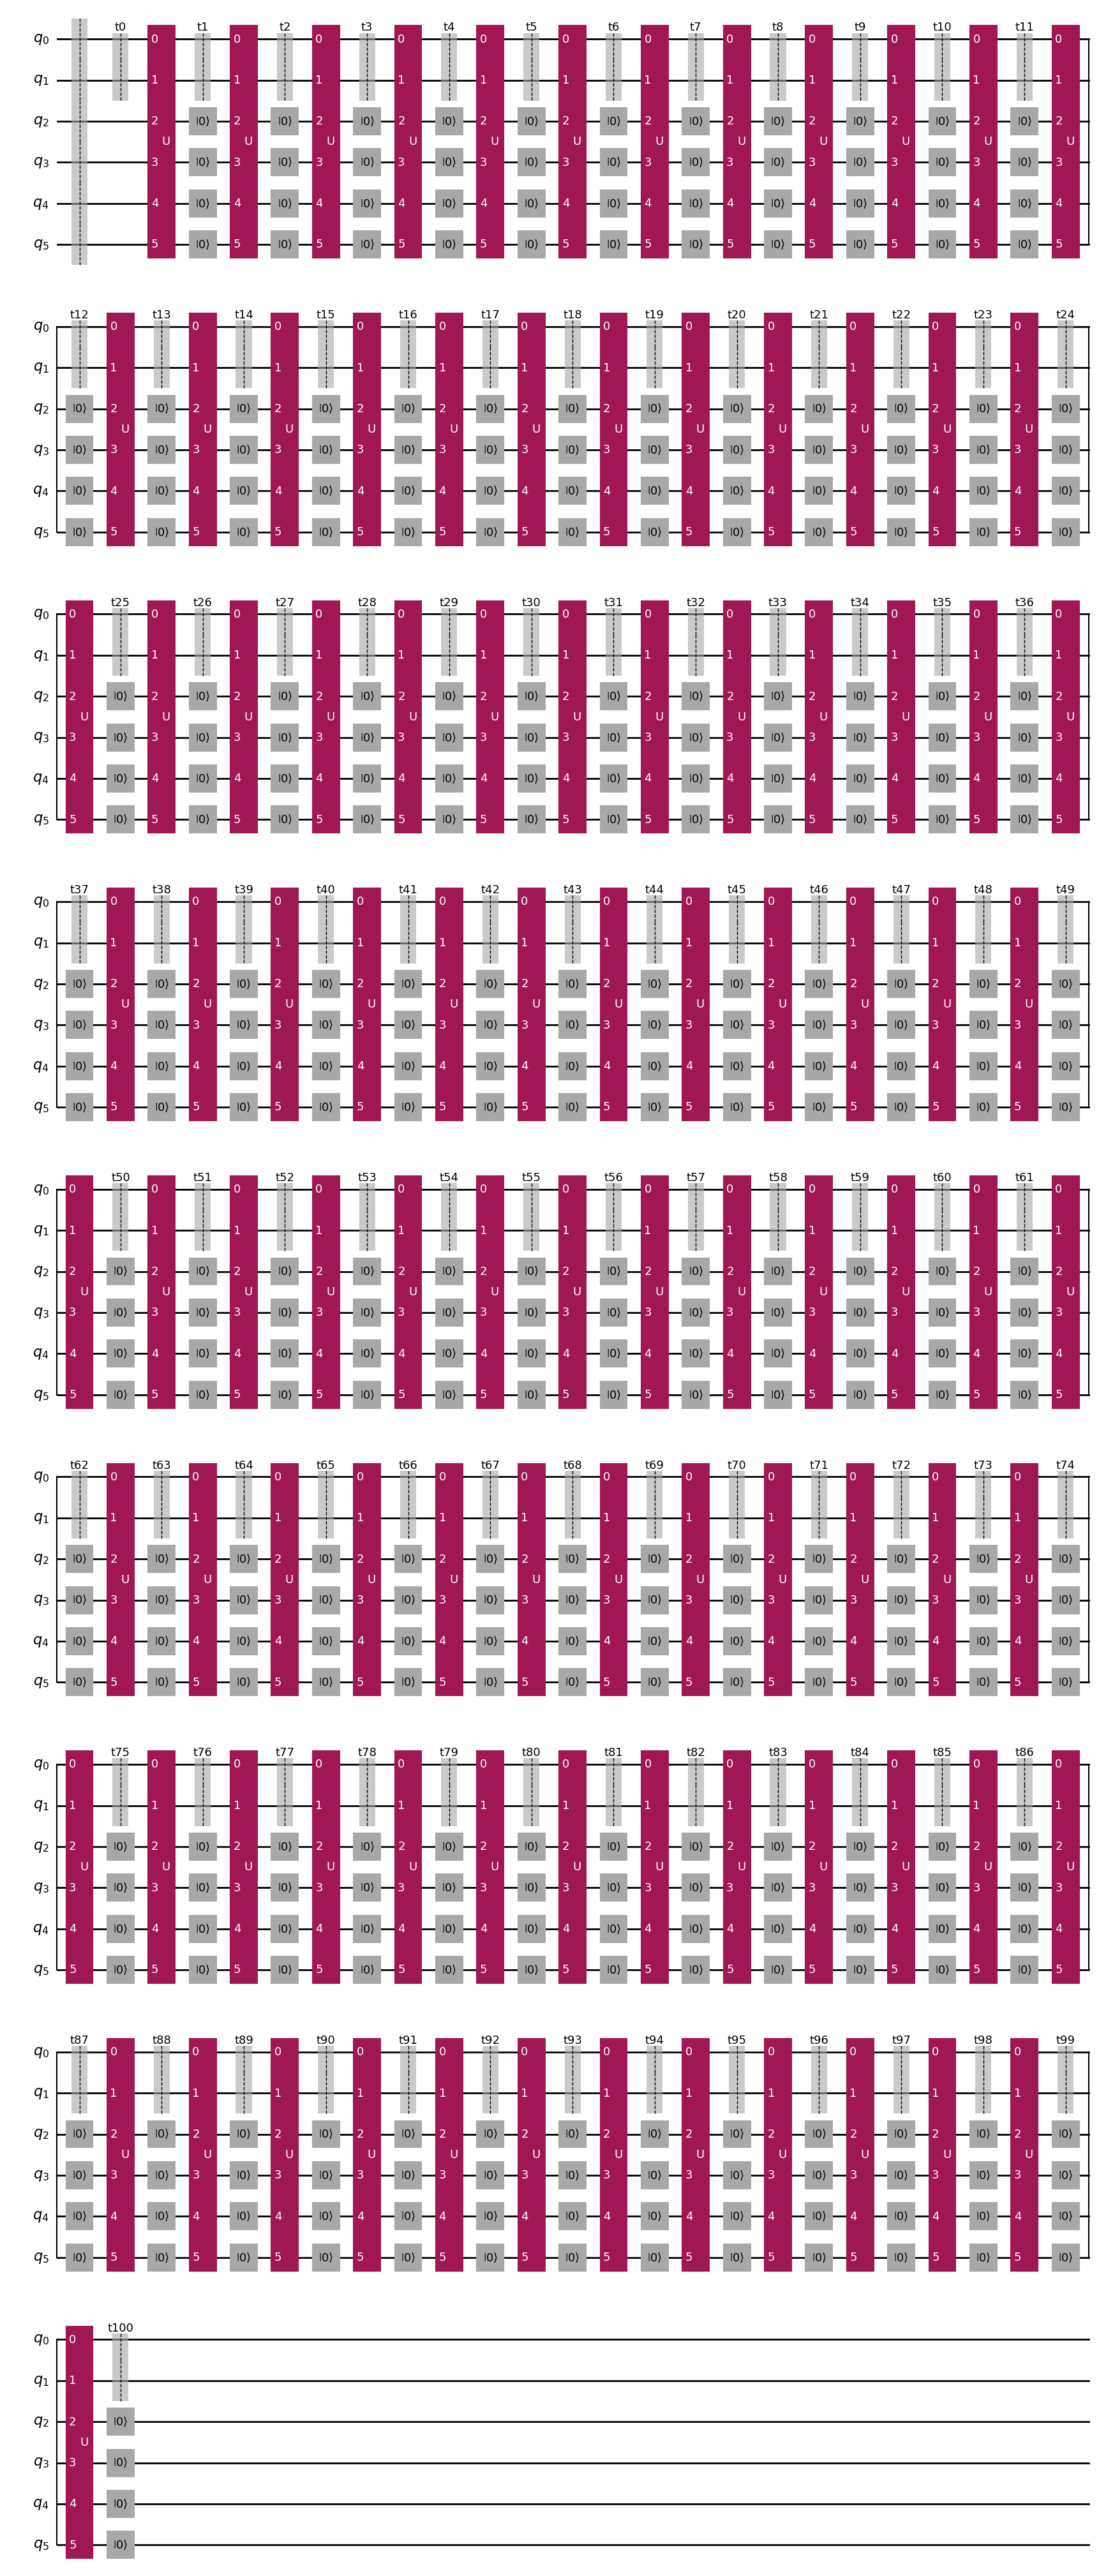

In [27]:
qc_A.draw(output='mpl')

## 5. Route B — Sz.-Nagy dilation and the price of non-complete-positivity

### Warum Stinespring in Route B bei $E$ scheitert
Die Stinespring-Dilatation (Satz 7 und 8 in deinem Text) ist maßgeschneidert für sogenannte Quantenkanäle. Das bedeutet, sie funktioniert ausschließlich für vollständig positive und spurerhaltende Abbildungen (CPTP-Maps). Damit du Stinespring anwenden kannst, müssen zwei harte Bedingungen erfüllt sein:
- Completely Positive (CP): Die Abbildung muss eine Kraus-Zerlegung $\Phi(\rho) = \sum_k M_k \rho M_k^\dagger$ besitzen.- Trace-Preserving (TP): Die Kraus-Operatoren müssen die Isometrie-Bedingung $\sum_k M_k^\dagger M_k = \mathbb{1}$ erfüllen.

Der Companion-Operator $E$ erfüllt keine dieser Bedingungen:
- Falscher Zustandsraum: $E$ wirkt nicht auf eine normale Dichtematrix $\rho$, sondern auf einen künstlich vergrößerten Blockvektor $X$, der ein gleitendes Fenster der letzten $K$ Zustände enthält (das "Gedächtnis"). Eine Abbildung, die Blockvektoren verschiebt und mit Transfer-Tensoren $T_m$ gewichtet, ist kein physikalischer Quantenkanal im Sinne einer CP-Map. Es gibt hier keine Kraus-Operatoren $M_k$ für $E$.
- Die Norm-Explosion (Nicht-Isometrisch): Die Isometrie-Bedingung von Stinespring ($\sum M_k^\dagger M_k = \mathbb{1}$) garantiert, dass die Spektralnorm strikt erhalten bleibt. Wie in Proposition 14 gezeigt wird, ist die Norm von $E$ jedoch $\Vert{}E\Vert{}_2 \approx \sqrt{2} > 1$. Ein Operator, dessen Norm größer als 1 ist, kann unmöglich Teil einer isometrischen Einbettung $V^\dagger V = \mathbb{1}$ sein.

Da $E$ weder CPTP ist noch die Norm erhält, existiert schlichtweg keine Isometrie $V$, die $E$ deterministisch in einen größeren unitären Raum einbettet.

### Warum Sz.-Nagy das Problem löst
Die Sz.-Nagy-Dilatation (Theorem 12) fragt nicht nach Quantenphysik. Sie ist ein universelles Resultat der linearen Algebra, das für jede beliebige Matrix $A$ funktioniert, solange diese eine Kontraktion ist (also $\Vert{}A\Vert{}_2 = \max_{x \neq 0} \frac{\Vert{}Ax\Vert{}}{\Vert{}x\Vert{}} \le 1$).Da uns die physikalische CPTP-Struktur fehlt, weichen wir auf dieses rein mathematische Theorem aus. Das Vorgehen sieht so aus:
- Schritt 1: Normierung zur Kontraktion:
Da $\Vert{}E\Vert{}_2 \approx \sqrt{2}$ größer als 1 ist, definieren wir eine skalierte Version:$$A = \frac{E}{s} \quad \text{mit} \quad s = \Vert{}E\Vert{}_2 \cdot (1 + 10^{-12})$$Jetzt ist garantiert, dass $\Vert{}A\Vert{}_2 \le 1$ gilt. $A$ ist eine Kontraktion.

- Schritt 2: Einbettung in eine unitäre Matrix:
Weil $A$ eine Kontraktion ist, können wir die Hermiteschen, positiv semidefiniten Matrizen $B = \sqrt{\mathbb{1} - AA^\dagger}$ und $C = \sqrt{\mathbb{1} - A^\dagger A}$ berechnen (Lemma 10). Damit lässt sich $A$ als oberer linker Block in eine größere unitäre Matrix $U$ einbauen:$$U = \begin{pmatrix} A & B \\ C & -A^\dagger \end{pmatrix}$$

**Der Preis für Sz.-Nagy: Post-Selection**:
Während Stinespring eine deterministische Abbildung liefert (die Umgebung wird am Ende einfach "vergessen" bzw. herausgetract, was mit Wahrscheinlichkeit $p=1$ funktioniert), erzwingt die mathematische Blockstruktur von Sz.-Nagy eine probabilistische Messung.Wenn wir $U$ auf unseren Zustand und ein frisches Ancilla-Qubit $\vert{}0\rangle$ anwenden, erhalten wir:$$U \begin{pmatrix} x \\ 0 \end{pmatrix} = \begin{pmatrix} A x \\ C x \end{pmatrix} = Ax \ket{0} + Cx \ket{1}$$
Damit wir unseren gewünschten Propagations-Schritt $Ax$ (also den oberen Block) erhalten, müssen wir das Ancilla-Qubit messen und zwingend das Ergebnis $\vert{}0\rangle$ erhalten. Wenn das Ancilla-Qubit als $\vert{}1\rangle$ gemessen wird (was dem unteren Block $Cx$ entspricht), ist die Simulation fehlgeschlagen und der Durchlauf muss verworfen werden.

### 5.1 When the square roots exist

> Lemma 10. Es gilt $\mathbb 1-AA^\dagger \succeq 0$ (die Matrix $\mathbb 1-AA^\dagger$ ist also positiv semidefinit) genau dann, wenn die Operatornorm $\Vert{}A\Vert{}_2 \le 1$ ist. Das Gleiche gilt analog für $\mathbb 1-A^\dagger A$.

Beweis. Schauen wir uns das Skalarprodukt für einen beliebigen Vektor $x$ an:$$\langle x, (\mathbb 1-AA^\dagger)x \rangle = \Vert{}x\Vert{}^2 - \Vert{}A^\dagger x\Vert{}^2$$Damit dieses Ergebnis für jedes mögliche $x$ nicht-negativ (also $\ge 0$) ist, darf die Matrix $A^\dagger$ den Vektor $x$ bei der Anwendung in seiner Länge niemals vergrößern. Das ist aber anschaulich exakt die Definition davon, dass die Operatornorm $\Vert{}A^\dagger\Vert{}_2 \le 1$ ist. Da für die Norm immer $\Vert{}A^\dagger\Vert{}_2 = \Vert{}A\Vert{}_2$ gilt, folgt der erste Teil direkt. Die zweite Aussage erhält man durch exakt dieselbe Rechnung, indem man einfach die Rollen von $A$ und $A^\dagger$ vertauscht. $\;\blacksquare$

Weil beide Operatoren hermitesch und positiv semidefinit sind, ist mathematisch garantiert, dass wir aus ihnen saubere Wurzeln ziehen können. Es existieren also ihre eindeutigen, positiven Quadratwurzeln $B := \sqrt{\mathbb 1-AA^\dagger}$ und $C := \sqrt{\mathbb 1-A^\dagger A}$.Hat man nun eine völlig allgemeine Matrix $A$ (deren Norm vielleicht größer als 1 ist), muss man diese Matrix zuerst mit einem Faktor $s \ge \Vert{}A\Vert{}_2$ herunterskalieren ("stauchen"), damit sie die Bedingung erfüllt. Der Code macht genau das und verwendet $s = \Vert{}A\Vert{}_2(1+10^{-12})$ – dieser winzige Puffer stellt sicher, dass wir wegen numerischer Rundungsfehler des Computers nicht aus Versehen minimal über 1 rutschen und die Wurzel plötzlich imaginär wird.

### 5.2 The dilation is unitary

> Lemma 11: Die Vertauschungsrelation: Für jede stetige Funktion $f$ im Intervall $[0, \Vert{}A\Vert{}_2^2]$ gilt:$$A^\dagger f(AA^\dagger) = f(A^\dagger A)A^\dagger$$

Stell dir vor, du hast eine Matrix $A^\dagger$, die vor einer Funktion steht. Du möchtest dieses $A^\dagger$ "durch die Funktion hindurchziehen" und auf die rechte Seite bringen. Dieses Lemma sagt: Das ist erlaubt, aber als Preis dafür musst du im Inneren der Funktion die Reihenfolge der Matrizen von $AA^\dagger$ zu $A^\dagger A$ umdrehen!

Der Beweis:

**Für einfache Potenzen:** Wir beweisen das zuerst für $f(x) = x^k$ mit vollständiger Induktion. Für $k=0$ ist es trivial ($A^\dagger \cdot \mathbb{1} = \mathbb{1} \cdot A^\dagger$).Für den Schritt von $k$ auf $k+1$ spalten wir eine Potenz ab:$$A^\dagger (AA^\dagger)^{k+1} = \big[A^\dagger (AA^\dagger)^k\big] AA^\dagger$$Nach unserer Induktionsannahme wissen wir schon, dass wir das $A^\dagger$ durch die $k$-te Potenz ziehen dürfen:
- Für $k=1$: $A^\dagger A A^\dagger = (A^\dagger A) A^\dagger$
- Für $k=2$: $A^\dagger (AA^\dagger) (AA^\dagger) = A^\dagger A A^\dagger A A^\dagger = (A^\dagger A) (A^\dagger A) A^\dagger =(A^\dagger A)^2 A^\dagger$
- Für allgemeines $k$: $\big[A^\dagger (AA^\dagger)^k\big] = (A^\dagger A)^k A^\dagger$
Also ersetzen wir die eckige Klammer:$$= (A^\dagger A)^k A^\dagger AA^\dagger = (A^\dagger A)^{k+1} A^\dagger$$Es funktioniert also für Potenzen! Wegen der Linearität (Superpositionsprinzip) funktioniert es damit auch für jedes beliebige Polynom (Summen von Potenzen).

**Für stetige Funktionen:** Eine beliebige stetige Funktion $f$ ist kein Polynom. Aber der Approximationssatz von Weierstraß besagt, dass wir jede stetige Funktion durch Polynome $p_n$ unendlich genau annähern können ($p_n \to f$).Da Matrizen endliche Spektren (Eigenwerte) haben, konvergiert diese Polynom-Annäherung auch für die Matrizen in der Operatornorm gegen null. Weil $AA^\dagger$ und $A^\dagger A$ bis auf den Eigenwert 0 exakt dieselben Eigenwerte besitzen, platzt bei diesem Grenzübergang nichts, und die Vertauschungsregel überträgt sich nahtlos auf die stetige Funktion $f$. $\;\blacksquare$

> Theorem 12: Die Sz.-Nagy DilatationTheorem 12 (Sz.-Nagy). Wenn die Operatornorm $\Vert{}A\Vert{}_2 \le 1$ ist, dann ist die folgende Blockmatrix unitär (es gilt also $U^\dagger U = \mathbb{1}$):$$U = \begin{pmatrix} A & B \\ C & -A^\dagger \end{pmatrix}$$wobei $B = \sqrt{\mathbb{1} - AA^\dagger}$ und $C = \sqrt{\mathbb{1} - A^\dagger A}$.

Der Beweis: 

Um zu zeigen, dass $U$ unitär ist, müssen wir $U^\dagger U$ ausrechnen. Zur Erinnerung: Beim Bilden von $U^\dagger$ wird die Matrix transponiert und komplex konjugiert. Die Matrizen $B$ und $C$ sind hermitesch (da sie Wurzeln aus positiv semidefiniten Matrizen sind, wie wir aus Lemma 10 wissen), also gilt $B^\dagger = B$ und $C^\dagger = C$.Unsere Multiplikation sieht also so aus:$$U^\dagger U = \begin{pmatrix} A^\dagger & C \\ B & -A \end{pmatrix} \begin{pmatrix} A & B \\ C & -A^\dagger \end{pmatrix}$$Wir rechnen nun die Block-Einträge der resultierenden $2 \times 2$ Matrix einzeln aus:
- Block oben links (1,1): Zeile 1 mal Spalte 1$$A^\dagger A + C^2 = A^\dagger A + (\mathbb{1} - A^\dagger A) = \mathbb{1}$$Das $A^\dagger A$ hebt sich perfekt auf.
- Block unten rechts (2,2): Zeile 2 mal Spalte 2$$B^2 + (-A)(-A^\dagger) = (\mathbb{1} - AA^\dagger) + AA^\dagger = \mathbb{1}$$Auch hier bleibt genau die Einheitsmatrix übrig.
- Block oben rechts (1,2): Zeile 1 mal Spalte 2$$A^\dagger B - C A^\dagger = A^\dagger \sqrt{\mathbb{1} - AA^\dagger} - \sqrt{\mathbb{1} - A^\dagger A} A^\dagger$$Hier scheint es auf den ersten Blick festzustecken, da Matrizen normalerweise nicht kommutieren. Aber hier kommt unser Lemma 11 ins Spiel! Unsere Funktion ist hier die Wurzelfunktion $f(x) = \sqrt{1-x}$. Da $\Vert{}A\Vert{}_2 \le 1$ ist, sind alle Eigenwerte $\le 1$, die Wurzel ist also immer reell und auf dem Intervall $[0,1]$ stetig.Nach Lemma 11 dürfen wir das $A^\dagger$ im ersten Term durch die Wurzel ziehen, wenn wir $AA^\dagger$ zu $A^\dagger A$ umdrehen. Der erste Term wird also exakt zum zweiten Term!$$= \sqrt{\mathbb{1} - A^\dagger A} A^\dagger - \sqrt{\mathbb{1} - A^\dagger A} A^\dagger = 0$$
- Block unten links (2,1):Da die Gesamtmatrix $U^\dagger U$ hermitesch ist, ist der Block unten links einfach das Adjungierte vom Block oben rechts. Und das Adjungierte von 0 ist wieder 0.

Die resultierende Matrix ist also $\begin{pmatrix} \mathbb{1} & 0 \\ 0 & \mathbb{1} \end{pmatrix}$, was der großen Einheitsmatrix entspricht. Damit ist bewiesen, dass $U$ unitär ist. $\;\blacksquare$

### 5.3 Post-selection and its probability

Wir präparieren das Ancilla-Qubit im Zustand $\vert{}0\rangle$ und unser System-Register im Zustand $\vert{}x\rangle$ mit der Länge $\Vert{}x\Vert{}=1$. $\ket{x}$ ist ein künstlicher "Super-Vektor", in den wir die gesamte Dichtematrix des Systems (also alle Populationen und Kohärenzen) zusammen mit ihrem Gedächtnis an die jüngste Vergangenheit (die letzten $K$ Zeitschritte) hineingepresst haben. In der Block-Notation schreiben wir das als den Vektor $(x,0)^{\mathsf T}$. Wenn wir nun unsere unitäre Matrix anwenden, erhalten wir:$$U\begin{pmatrix}x\\0\end{pmatrix}=\begin{pmatrix}(A/s)\,x\\ C\,x\end{pmatrix} = (A/s)\,x \ket{0} + C\,x \ket{1} $$Diese beiden Komponenten repräsentieren die Zweige, in denen das Ancilla-Qubit $\vert{}0\rangle$ bzw. $\vert{}1\rangle$ ist. Ihre Normen (Längenquadrate) addieren sich exakt zu 1, wie es in der Quantenmechanik sein muss:
$$\Vert{}(A/s)x\Vert{}^2+\Vert{}Cx\Vert{}^2=\big\langle x,(A/s)^\dagger(A/s)x\big\rangle+\big\langle x,(\mathbb 1-(A/s)^\dagger(A/s))x\big\rangle=\Vert{}x\Vert{}^2 .$$
Nach der Bornschen Regel liefert die Messung des Ancilla-Qubits mit $\Vert{}x\Vert{}=1$ das Ergebnis $\vert{}0\rangle$ mit der Wahrscheinlichkeit
$$p=\big\Vert{}(A/s)x\big\Vert{}^2=\frac{\Vert{}Ax\Vert{}^2}{s^2\Vert{}x\Vert{}^2} = \frac{\Vert{}Ax\Vert{}^2}{s^2} \tag{5.2}$$
und bedingt auf dieses Messergebnis wird das System-Register in den Zustand $(A/s)x$ geworfen. Das heißt, der resultierende Zustand ist $Ax/\Vert{}Ax\Vert{}$.Die Post-Selection wendet also unsere gewünschte Matrix $A$ an, bis auf die Normierung. Das ist völlig ausreichend, da wir den physikalischen Skalierungsfaktor einfach klassisch auf dem Computer mitverfolgen können (§5.5).

### 5.4 Many steps

> Proposition 13. Sei $x_{t+1} := Ax_t$ die Folge unserer unnormierten, theoretischen Vektoren. Wenn der Quantenschaltkreis die Sz.-Nagy-Dilatation $n$-mal hintereinander anwendet (jedes Mal mit einem neuen Ancilla-Qubit) und wir bei jedem dieser Qubits fordern, dass es als $\vert{}0\rangle$ gemessen wird (Post-Selection), dann ist die Gesamtwahrscheinlichkeit dafür:$$p_{\rm total} = \prod_{t=0}^{n-1}p_t = \frac{\Vert{}A^{n}x_0\Vert{}^{2}}{s^{2n}\Vert{}x_0\Vert{}^{2}}. \tag{5.3}$$

Beweis. Wir definieren $y_t := x_t / \Vert{}x_t\Vert{}$ als den normierten echten Quantenzustand, der in den Schritt $t$ hineingeht. Nach Gleichung (5.2) ist die Wahrscheinlichkeit für einen Erfolg in diesem einzelnen Schritt:$$p_t = \frac{\Vert{}Ay_t\Vert{}^2}{s^2} = \frac{\Vert{}Ax_t\Vert{}^2}{s^2\Vert{}x_t\Vert{}^2} = \frac{\Vert{}x_{t+1}\Vert{}^2}{s^2\Vert{}x_t\Vert{}^2}.$$Wenn wir nun all diese Wahrscheinlichkeiten miteinander multiplizieren, entsteht ein Teleskopprodukt:
$$\prod_{t=0}^{n-1}p_t = \frac{1}{s^{2n}}\prod_{t=0}^{n-1}\frac{\Vert{}x_{t+1}\Vert{}^2}{\Vert{}x_t\Vert{}^2} = \frac{1}{s^{2n}} \cdot \left( \frac{\color{red}{\cancel{\Vert{}x_1\Vert{}^2}}}{\Vert{}x_0\Vert{}^2} \cdot \frac{\color{lightblue}{\cancel{\Vert{}x_2\Vert{}^2}}}{\color{red}{\cancel{\Vert{}x_1\Vert{}^2}}} \cdot \frac{\color{green}{\cancel{\Vert{}x_3\Vert{}^2}}}{\color{lightblue}{\cancel{\Vert{}x_2\Vert{}^2}}} \cdot \dots \cdot \frac{\color{orange}{\cancel{\Vert{}x_{n-1}\Vert{}^2}}}{\color{purple}{\cancel{\Vert{}x_{n-2}\Vert{}^2}}} \cdot \frac{\Vert{}x_n\Vert{}^2}{\color{orange}{\cancel{\Vert{}x_{n-1}\Vert{}^2}}} \right) = \frac{1}{s^{2n}}\cdot\frac{\Vert{}x_n\Vert{}^2}{\Vert{}x_0\Vert{}^2},$$
und da nach Definition $x_n = A^nx_0$ gilt, ist der Beweis abgeschlossen. $\;\blacksquare$

Ob wir die Ancilla-Qubits sofort nach ihrem jeweiligen Schritt messen oder alle gemeinsam ganz am Ende, spielt physikalisch überhaupt keine Rolle: Sobald der Zeitschritt $t$ vorbei ist, berührt kein einziges Gatter dieses spezifische Ancilla-Qubit $t$ jemals wieder. Daher vertauscht (kommutiert) diese Messung mit allem, was danach im Schaltkreis passiert, und die statistischen Resultate bleiben exakt gleich. Das ist das Prinzip der aufgeschobenen Messung (Deferred-Measurement Principle). Genau dieses Prinzip ermöglicht es, die Simulation als einen einzigen, durchgehenden Schaltkreis zu bauen, anstatt den Schaltkreis $n$-mal bedingt neu starten zu müssen.

Formel (5.3) offenbart die eigentliche Hürde der Route B. Für unseren ursprünglichen Begleitoperator (Companion Operator) gilt $\Vert{}E\Vert{}_2 = \sqrt{2}$, während sein Spektralradius $\rho(E) = 1$ ist. Für $n=76$ Zeitschritte ergibt das $s= \sqrt{2}^{2\cdot 76} = 2^{76}$ und somit:

$$p_{\rm total} = \frac{\Vert{}E^{n}x_0\Vert{}^{2}}{s^{2n}\Vert{}x_0\Vert{}^{2}} =\frac{1}{2^{76}}\cdot\frac{\Vert{}x_n\Vert{}^2}{\Vert{}x_0\Vert{}^2} \simeq \frac{\mathcal O(1)}{2^{76}} \approx 6.7 \times 10^{-24},$$

man bräuchte also grob $10^{23}$ Durchläufe (Shots) für auch nur ein einziges verwertbares Messergebnis.

### 5.5 The classical scale factor
Dieser Abschnitt beschreibt einen wunderschönen Trick der hybriden Quanten-Klassik-Algorithmen. Er beantwortet die Frage: Wie können wir eine Dynamik simulieren, bei der die Vektoren (Wahrscheinlichkeiten) schrumpfen sollen, wenn der Quantencomputer uns zwingt, immer Vektoren der Länge 1 zu haben? Die Lösung: Arbeitsteilung!
- Der Quantencomputer kümmert sich nur um die Richtung des Vektors im Raum (die relativen Amplituden $y_t$). Er hat keine Ahnung, wie lang der Vektor eigentlich sein sollte.
- Dein klassischer Laptop kümmert sich nur um die Länge des Vektors (den Skalar $\lambda_t$).

Wir definieren $\lambda_t$ einfach als die Länge unseres theoretischen Papier-Vektors: $\lambda_t = \Vert{}x_t\Vert{}$. Wir wollen berechnen, wie lang der Vektor im nächsten Schritt ($t+1$) sein wird.
- Die Logik: $\lambda_{t+1} = \Vert{}x_{t+1}\Vert{} = \Vert{}A x_t\Vert{}$. Das ist einfach unsere Vorschrift: Der neue Vektor entsteht, indem wir den alten mit $A$ multiplizieren.
- Der geniale Ersetzungsschritt: Wir erinnern uns an unsere Wahrscheinlichkeitsformel (5.2) von vorhin:$$p_t = \frac{\Vert{}Ax_t\Vert{}^2}{s^2\Vert{}x_t\Vert{}^2}$$ Wenn wir diese Gleichung nach der neuen Länge $\Vert{}Ax_t\Vert{}$ umstellen (also mit dem Nenner multiplizieren und dann die Wurzel ziehen), erhalten wir:$$\Vert{}Ax_t\Vert{} = s\sqrt{p_t}\;\Vert{}x_t\Vert{}$$
- Das klassische Update: Da $\Vert{}x_t\Vert{}$ genau unser aktueller Skalar $\lambda_t$ ist, lautet die finale Regel:$$\lambda_{t+1} = s\sqrt{p_t}\,\lambda_t$$

- Die Arbeitsteilung: Der Quantencomputer berechnet in jedem Schritt ausschließlich die Richtung des Vektors, da die Gesetze der Quantenmechanik ihn nach jeder Messung wieder auf die Länge 1 aufblasen. Dein klassischer Rechner (Laptop) führt parallel dazu "Buch" über die schrumpfende Länge in Form des Skalierungsfaktors $\lambda$. Die Länge von $\ket{x}$ schrumpft weil die Summe der Quadrate der Dichtematrixeinträge kleiner wird wenn sich die excitation von ursprünglich 1 auf $\rho_{00}$ auf mehrere Matrixelemente verteilt.

- Das klassische Update: In jedem einzelnen Zeitschritt misst du das Ancilla-Qubit. Die Häufigkeit, mit der du eine Null misst, liefert dir die Wahrscheinlichkeit $p_t$. Mit genau diesem $p_t$ rechnest du auf dem Laptop aus, um welchen Faktor der Vektor gerade geschrumpft ist, und aktualisierst dein $\lambda$ für den nächsten Schritt.

- Das große Finale: Am Ende der Simulation ($t=n$) liefert dir der Quantencomputer einen normierten Vektor. Du nimmst diesen Vektor und multiplizierst ihn einfach mit deinem über alle Schritte angesammelten End-Faktor $\lambda_n$.

- Das Resultat: Durch diese Multiplikation erhältst du exakt den unnormierten, physikalisch korrekten Vektor zurück. Diesen musst du dann nur noch zu deiner endgültigen Dichtematrix umformen (reshapen).

## 6. The operator norm is the wrong quantity — compressing onto the reachable subspace

### 6.1 Where the $\sqrt2$ comes from, and why it is unphysical

Der exponentielle Vorfaktor in (5.3) wird durch $s = \Vert{}E\Vert{}_2$ diktiert, was per Definition das Supremum (der Worst-Case-Maximalwert) über das gesamte Register ist:$$\Vert{}E\Vert{}_2 = \sup_{X\neq 0} \frac{\Vert{}EX\Vert{}}{\Vert{}X\Vert{}}.$$Die folgende Rechnung zeigt exakt, welches $X$ diesen Maximalwert erreicht – und dass kein physikalischer Zustand auch nur annähernd so aussieht.
> Proposition 14. Schreiben wir $X = (x_1,\dots,x_K)$ in Blöcken. Dann gilt:$$\Vert{}EX\Vert{}^2-\Vert{}X\Vert{}^2 = \Big\Vert{}\sum_{m=1}^{K}T_mx_m\Big\Vert{}^2-\Vert{}x_K\Vert{}^2 . \tag{6.1}$$Insbesondere gilt $\Vert{}E\Vert{}_2^2 \ge 1+\Vert{}T_1\Vert{}_2^2$, wobei diese untere Schranke von Zuständen erreicht wird, die ausschließlich im allerersten Block besetzt sind.

Beweis. Nach Gleichung (3.4) ist $EX = \big(\sum_m T_m x_m,\; x_1,\; x_2,\dots,x_{K-1}\big)$. Da die Blöcke orthogonal (unabhängig voneinander) sind, gilt:$$\Vert{}EX\Vert{}^2 = \Big\Vert{}\sum_m T_m x_m\Big\Vert{}^2 + \sum_{i=1}^{K-1}\Vert{}x_i\Vert{}^2, \qquad \Vert{}X\Vert{}^2 = \sum_{i=1}^{K}\Vert{}x_i\Vert{}^2,$$ und wenn man beides voneinander abzieht, erhält man (6.1). Für die Schranke wählen wir $X = (x,0,\dots,0)$ mit $\Vert{}x\Vert{}=1$: dann ist $\Vert{}EX\Vert{}^2 = \Vert{}T_1x\Vert{}^2 + 1$, und wenn wir das über alle $x$ maximieren, ergibt das $\Vert{}E\Vert{}_2^2 \ge \Vert{}T_1\Vert{}_2^2 + 1$. $\;\blacksquare$

Erinnern wir uns nun aus Proposition 5, dass $T_1 = \mathcal L_1 = \mathcal L(\Delta t)$ die Abbildung für einen einzigen Zeitschritt ist. Für einen kleinen Zeitschritt $\Delta t$ ist diese fast identisch mit der Einheitsmatrix und hat insbesondere $\Vert{}T_1\Vert{}_2 \approx 1$. Proposition 14 sagt also voraus, dass $\Vert{}E\Vert{}_2 \approx \sqrt{2}$ ist — und das ist exakt der Wert, den wir auch messen. Aber der Zustand, der dieses Maximum erreicht, hat nur einen einzigen besetzten Block. Das entspricht einem Historien-Fenster, in dem das System in diesem einen Moment existierte, aber in allen $K-1$ vorherigen Zeitschritten identisch null war (also gar nicht existierte). Das ist keine physikalische Konfiguration.

Ein physikalisches $X$ hat in allen $K$ Blöcken vergleichbare Normen, $\Vert{}x_i\Vert{} = \Vert{}\rho_{n-i+1}\Vert{}_F \in [d^{-1/2}, 1]$. Gleichung (6.1) besagt dann, dass sich die Norm des Gesamtsystems nur um die kleine Differenz zwischen der neu berechneten Zeitscheibe und der verworfenen ältesten Zeitscheibe ändert, eine Differenz, die sich über $K$ Blöcke verteilt. Daher bleibt das Längenverhältnis nahe bei 1, und tatsächlich messen wir entlang der echten Trajektorie:
$$\frac{\Vert{}EX_n\Vert{}}{\Vert{}X_n\Vert{}} \in [0.982,\,0.998],\qquad\text{Mittelwert } 0.9955 .$$

### 6.2 Arnoldi compression

Let $\mathcal K_m(E,X_0):=\operatorname{span}\{X_0,EX_0,\dots,E^{m-1}X_0\}$ be the Krylov space, which by
construction contains the entire reachable trajectory. The Arnoldi process builds an orthonormal basis of
it: set $q_1:=X_0/\|X_0\|$ and, for $j=1,2,\dots$,
$$h_{ij}:=\langle q_i,Eq_j\rangle\;(i\le j),\qquad
w_j:=Eq_j-\sum_{i=1}^{j}h_{ij}q_i,\qquad
h_{j+1,j}:=\|w_j\|,\qquad q_{j+1}:=w_j/h_{j+1,j}. \tag{6.2}$$

> **Proposition 15.** With $Q_m:=(q_1\cdots q_m)$ and $H_m:=(h_{ij})_{i,j\le m}$ upper Hessenberg,
> $$E\,Q_m=Q_mH_m+h_{m+1,m}\,q_{m+1}e_m^{\mathsf T},\qquad H_m=Q_m^\dagger E\,Q_m . \tag{6.3}$$

*Proof.* Rearranging (6.2) gives $Eq_j=\sum_{i=1}^{j+1}h_{ij}q_i$, which for $j<m$ is column $j$ of
$Q_mH_m$ and for $j=m$ carries the extra term $h_{m+1,m}q_{m+1}$; collecting the columns yields the first
identity. Multiplying it by $Q_m^\dagger$ and using $Q_m^\dagger Q_m=\mathbb 1_m$ together with
$Q_m^\dagger q_{m+1}=0$ (the vectors are orthonormal by construction) gives the second. $\;\blacksquare$

> **Proposition 16.** $\|H_m\|_2\le\|E\|_2$.

*Proof.* For any $y\in\mathbb C^m$, $\|H_my\|=\|Q_m^\dagger EQ_my\|\le\|EQ_my\|\le\|E\|_2\|Q_my\|=\|E\|_2\|y\|$,
where the first inequality holds because $Q_m^\dagger$ is a contraction ($\|Q_m^\dagger\|_2=\|Q_m\|_2=1$
for an isometry) and the last equality because $Q_m$ preserves norms. $\;\blacksquare$

Proposition 16 only guarantees no increase; the useful statement is quantitative and follows from §6.1:
compression removes precisely the unvisited, norm-inflating directions identified in Proposition 14, and
numerically $\|H_{32}\|_2=1.0028$ against $\|E\|_2=1.4142$.

> **Proposition 17.** If $h_{m+1,m}=0$, then $\mathcal K_m$ is $E$-invariant and
> $$E^{\,n}X_0=\|X_0\|\,Q_mH_m^{\,n}e_1\qquad\text{for all }n\ge0. \tag{6.4}$$

*Proof.* With $h_{m+1,m}=0$, (6.3) reduces to $EQ_m=Q_mH_m$. Then $E^2Q_m=E Q_mH_m=Q_mH_m^2$, and
inductively $E^nQ_m=Q_mH_m^n$. Since $X_0=\|X_0\|\,q_1=\|X_0\|\,Q_me_1$, applying $E^n$ gives (6.4).
$\;\blacksquare$

When $h_{m+1,m}\neq0$ the deviation is controlled by that residual, which is why the trajectory error in
the table falls monotonically as $m$ grows.

### 6.3 The consequence, and the trade-off

Dilating $H_m$ rather than $E$ changes (5.3) from $s^{-2n}=2^{-n}$ to $\|H_m\|_2^{-2n}\approx1$. For
$n=76$ steps this turns
$$p_{\rm total}=6.7\times10^{-24}\quad\longrightarrow\quad p_{\rm total}=0.328,$$
three shots per sample, while simultaneously shrinking the register from $KD=400$ dimensions ($10$ qubits)
to $m=32$ ($6$ qubits including the ancilla). The physical state is recovered as
$\operatorname{vec}\rho_t=\lambda_t\,\Pi\,Q_m\,y_t$ with $\lambda_t$ the scalar of §5.5.

The choice of $m$ is a genuine trade-off, not a convergence parameter. Small $m$ truncates the trajectory
(the residual $h_{m+1,m}$ in Proposition 17 is large); large $m$ lets Arnoldi reach into the very
directions Proposition 14 identified as norm-inflating, so $\|H_m\|_2$ creeps up and (5.3) degrades again.
For HEOM the optimum is broad ($m=32$: error $1.5\times10^{-3}$, $p=0.33$); for the path integral, whose
$E$ is assembled from MPS-truncated maps and is markedly more non-normal, $m=64$ already gives
$\|H_m\|_2=1.243$ and hence $p=2.5\times10^{-18}$.

## 7. What is actually read out, and the question of intermediate times

The two routes differ in what the final measurement has to accomplish, and the difference is one of
encoding rather than of effort.

Route A stores $\rho$ *as a density matrix* on $n_{\rm sys}=\lceil\log_2d\rceil$ qubits. The populations
are then the diagonal, $p_i=\langle i|\rho|i\rangle$, which is precisely the outcome distribution of a
computational-basis measurement: repeating the circuit and histogramming the results estimates every
$p_i$ to accuracy $\varepsilon$ with $\mathcal O(1/\varepsilon^2)$ shots. No tomography is involved at
any stage, and coherences would require only the usual change of measurement basis.

Route B stores $\operatorname{vec}\rho$ *as amplitudes* of a normalised pure register state. A
computational-basis measurement returns $|(\operatorname{vec}\rho)_a|^2$ up to normalisation, so phases —
and hence the coherences — need amplitude estimation, for instance a Hadamard test against a reference
state. The essential point is that this happens **once, at the end of the run**, never between steps: the
$\lambda_t$ of §5.5 come from counting ancilla outcomes, not from reconstructing a state.

Finally the trajectory. The snapshots produced by the code come from the simulator instruction
`save_density_matrix`, which reads the simulator's own memory and has no physical counterpart. On
hardware a measurement at time $t$ collapses the state and the evolution cannot be continued, so the full
trajectory would cost one run per target $T$, each run internally continuous and tomography-free.

Whether all times can nevertheless be obtained from a *single* run with a *single* measurement is the
subject of §8, and the answer turns out to be yes, at a cost of only $\lceil\log_2(n+1)\rceil+1$
additional qubits.

---

## Route B — HEOM / path integral: one circuit, only the ancilla is measured

The memory-enhanced operator $E$ (transfer tensors on a $K$-step register) is **not** completely
positive, so no Stinespring dilation exists and post-selection is unavoidable. Done naively this is
hopeless: $\|E\|_2=\sqrt2$, so $76$ steps succeed with probability $\sim s^{-2n}=10^{-24}$.

But $\|E\|_2$ is a worst-case bound over the whole $K\!\cdot\!D$-dimensional register, and the physical
trajectory never goes there — along it, $\|EX\|/\|X\|\approx0.995$. So we first **compress $E$ onto the
reachable (Krylov) subspace** with Arnoldi, $H_m=Q_m^\dagger E Q_m$, which has $\|H_m\|_2\approx1.003$,
and dilate *that*. This shrinks the register **and** lifts the success probability by ~23 orders of
magnitude.

$m$ trades accuracy against cost: too small and the trajectory is wrong, too large and $H_m$ picks up
non-normal directions that push $\|H_m\|_2$ back up.

In [4]:
def arnoldi(E, x0, m):
    """Orthonormal basis Q_m of the Krylov space and H_m = Q_m^dag E Q_m."""
    Q = np.zeros((E.shape[0], m + 1), complex); Q[:, 0] = x0 / np.linalg.norm(x0)
    H = np.zeros((m + 1, m), complex); mm = m
    for j in range(m):
        w = E @ Q[:, j]
        for i in range(j + 1):
            H[i, j] = np.vdot(Q[:, i], w); w -= H[i, j] * Q[:, i]
        H[j + 1, j] = np.linalg.norm(w)
        if H[j + 1, j] < 1e-13:
            mm = j + 1; break
        Q[:, j + 1] = w / H[j + 1, j]
    return H[:mm, :mm], Q[:, :mm]


def dilate(A):
    """Sz.-Nagy: A/s as the top-left block of a unitary one qubit larger."""
    n = A.shape[0]; s = float(np.linalg.norm(A, 2)) * (1 + 1e-12); As = A / s
    I = np.eye(n)
    B = sqrtm(I - As @ As.conj().T); C = sqrtm(I - As.conj().T @ As)
    B, C = 0.5 * (B + B.conj().T), 0.5 * (C + C.conj().T)
    return np.block([[As, B], [C, -As.conj().T]]), s


def propagate_memory_single(E, X0, n_steps, m, d):
    """ONE circuit for the non-Markovian case. The memory register is never
    measured and never re-prepared; only the ancilla is read out each step and
    runs with a |1> outcome are discarded. Returns (pops, circuit, info)."""
    D = d * d
    Hm, Qm = arnoldi(E, X0, m); m = Hm.shape[0]
    mp = 1 << int(np.ceil(np.log2(m)))
    A = np.zeros((mp, mp), complex); A[:m, :m] = Hm
    U, s = dilate(A)
    nq = int(np.log2(mp))

    qr, ar = QuantumRegister(nq, 'mem'), QuantumRegister(1, 'anc')
    cr = ClassicalRegister(n_steps, 'ok')
    qc = QuantumCircuit(qr, ar, cr)
    y = np.zeros(mp, complex); y[0] = 1.0
    qc.initialize(np.concatenate([y, np.zeros(mp)]), list(qr) + list(ar))
    gate = UnitaryGate(U, label='H_m')
    for t in range(n_steps):
        qc.append(gate, list(qr) + list(ar))
        qc.measure(ar[0], cr[t])        # ONLY the ancilla
        qc.reset(ar[0])

    # the |0...0> branch the post-selection keeps, with the classical norm bookkeeping
    scale = np.linalg.norm(X0); yv = y.copy(); p_tot = 1.0
    pops = [np.real(np.diag((Qm @ yv[:m] * scale)[:D].reshape(d, d, order='F')))]
    for _ in range(n_steps):
        top = (U @ np.concatenate([yv, np.zeros(mp)]))[:mp]
        nrm = np.linalg.norm(top); p_tot *= nrm ** 2
        yv = top / nrm; scale = scale * nrm * s
        pops.append(np.real(np.diag((Qm @ yv[:m] * scale)[:D].reshape(d, d, order='F'))))
    return np.array(pops), qc, dict(m=m, n_qubits=nq + 1, s=s, p_success=p_tot,
                                    norm_Hm=float(np.linalg.norm(Hm, 2)))

In [5]:
M_KRYLOV = 32          # compression dimension: accuracy vs success probability
out_B = {}

for name in ('HEOM', 'Path integral'):
    E, K = res[name]['E'], res[name]['K']
    X0 = np.concatenate([res[name]['rho'][i].flatten(order='F') for i in range(K)][::-1])
    pops, qc, info = propagate_memory_single(E, X0, len(t_fs) - K, M_KRYLOV, d)
    out_B[name] = (pops, qc, info)
    full_reg = E.shape[0]
    print(f"{name:14s} register {full_reg} -> {info['m']} (Krylov), "
          f"{info['n_qubits']} qubits, depth {qc.depth()}")
    print(f"{'':14s} ||H_m|| = {info['norm_Hm']:.4f}, "
          f"p_success = {info['p_success']:.3e} ({1 / info['p_success']:.1f} shots/sample), "
          f"naive would be {(1 / np.linalg.norm(E, 2) ** 2) ** (len(t_fs) - K):.1e}")
    print(f"{'':14s} vs stored result: {np.abs(pops - res[name]['pops'][K - 1:]).max():.2e}\n")

HEOM           register 400 -> 32 (Krylov), 6 qubits, depth 229
               ||H_m|| = 1.0028, p_success = 3.283e-01 (3.0 shots/sample), naive would be 1.3e-23
               vs stored result: 3.49e-04

Path integral  register 160 -> 32 (Krylov), 6 qubits, depth 274
               ||H_m|| = 1.0374, p_success = 4.882e-04 (2048.2 shots/sample), naive would be 4.0e-28
               vs stored result: 1.73e-04



## One circuit vs the step-by-step implementation

Solid = produced by a single continuous circuit, dashed black = the existing per-step result. They lie
on top of each other, which is the point: nothing was lost by removing the intermediate read-out.

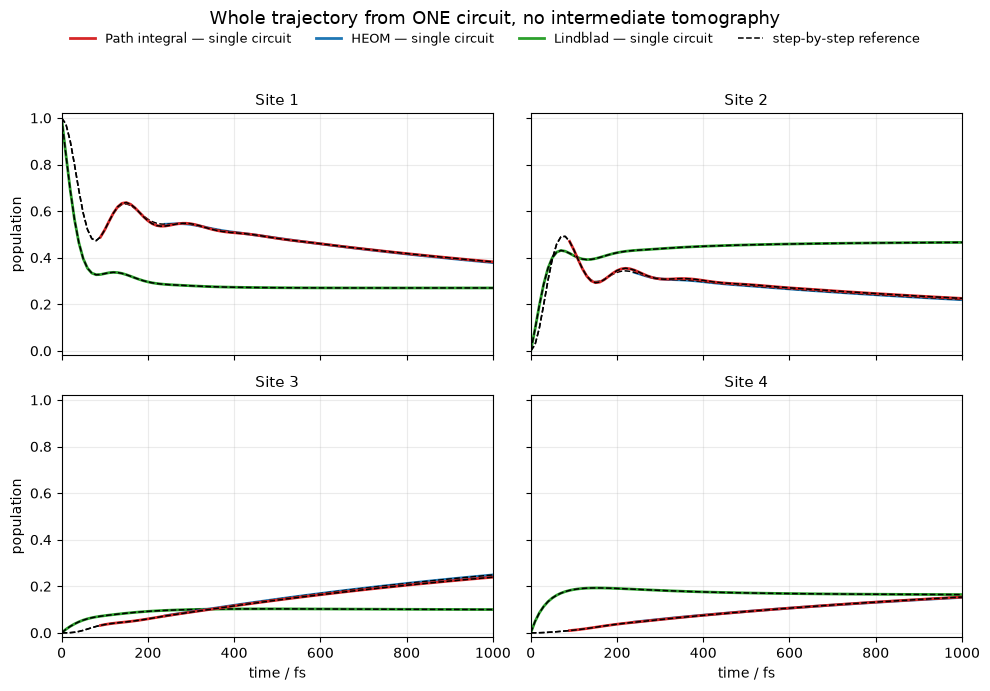

wrote pictures/single_grid_N4.png


In [6]:
col = {'Lindblad': '#2ca02c', 'HEOM': '#1f77b4', 'Path integral': '#d62728'}
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for site, ax in enumerate(axes.flat):
    ax.plot(t_fs, pops_A[:, site], color=col['Lindblad'], lw=2.0)
    ax.plot(t_fs, res['Lindblad']['pops'][:, site], color='k', ls='--', lw=1.1)
    for name in ('HEOM', 'Path integral'):
        K = res[name]['K']
        ax.plot(t_fs[K - 1:], out_B[name][0][:, site], color=col[name], lw=2.0)
        ax.plot(t_fs, res[name]['pops'][:, site], color='k', ls='--', lw=1.1)
    ax.set_title(f'Site {site + 1}', fontsize=11)
    ax.set_xlim(0, t_fs[-1]); ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.25)
    if site >= 2: ax.set_xlabel('time / fs')
    if site % 2 == 0: ax.set_ylabel('population')

from matplotlib.lines import Line2D
handles = [Line2D([], [], color=col[n], lw=2.0,
                  label=f'{n} — single circuit') for n in ('Path integral', 'HEOM', 'Lindblad')]
handles.append(Line2D([], [], color='k', ls='--', lw=1.1, label='step-by-step reference'))
fig.legend(handles=handles, loc='upper center', ncol=4, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, 0.965))
fig.suptitle('Whole trajectory from ONE circuit, no intermediate tomography', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(f'pictures/single_grid_N{N}.png', dpi=200); plt.show()
print(f'wrote pictures/single_grid_N{N}.png')

## The two grids, drawn next to their formulas

Below are the circuits themselves, truncated to three steps so the repeating unit is legible. Each
element corresponds to one object from the theory.

**Left — route A, the deterministic grid of §4.** The register `sys` carries $\rho$ itself on
$n_{\rm sys}=\lceil\log_2 d\rceil=2$ qubits; `env` is the $n_{\rm env}=\lceil\log_2K\rceil=4$ qubit
environment of the Stinespring dilation. The box $U_S$ is the unitary completion
$U=[\,V\,|\,w_1\cdots\,]$ with $V|\psi\rangle=\sum_k|k\rangle_E\otimes M_k|\psi\rangle$, and it is
applied to `sys` first and `env` second precisely to realise the index convention
$\text{index}=k\cdot2^{n_{\rm sys}}+i$. The $|0\rangle$ symbols on the `env` wires are the resets, i.e.
the partial trace $\operatorname{Tr}_E$ that turns $U$ back into the channel $\Phi$. There is no meter
anywhere: every step has probability $1$, and the state on `sys` after $t$ repetitions is
$\Phi^t(\rho_0)$.

**Right — route B, the post-selected grid of §5–§6.** The register `mem` holds the *normalised Krylov
coefficient vector* $y_t$ on $\lceil\log_2m\rceil=5$ qubits — not $\rho$ itself, but the compressed
representation of the whole history window $X_t$ through $\operatorname{vec}\rho_t=\lambda_t\Pi Q_my_t$.
The box $U_H$ is the Sz.-Nagy dilation of $H_m/s$ with $s=\|H_m\|_2=1.0028$, and `anc` is its single
ancilla. Here a meter *does* appear on `anc` after every step: that is the post-selection on
$|0\rangle$ which projects onto the $(H_m/s)y_t$ branch with probability $p_t$. The meter never touches
`mem`, and `mem` is never re-prepared — the state simply continues. The reset returns `anc` to
$|0\rangle$ so the same ancilla can serve the next step.

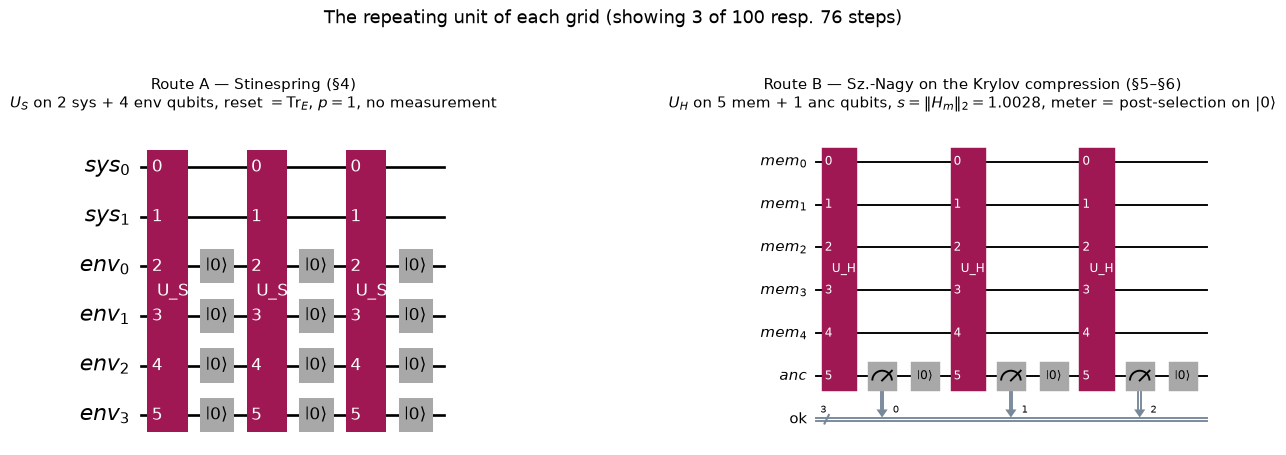

wrote pictures/single_grid_circuits_N4.png


In [ ]:
SHOW_STEPS = 3          # the repeating unit; the real circuits have 100 resp. 76 of these

# ---- route A: sys (rho itself) + env, U_S, reset, no meter --------------
U_A, ns_A, ne_A = stinespring_unitary(res['Lindblad']['kraus_dt'], d)
sysA, envA = list(range(ns_A)), list(range(ns_A, ns_A + ne_A))
qc_A_show = QuantumCircuit(QuantumRegister(ns_A, 'sys'), QuantumRegister(ne_A, 'env'))
for _ in range(SHOW_STEPS):
    qc_A_show.append(UnitaryGate(U_A, label='U_S'), sysA + envA)
    qc_A_show.reset(envA)

# ---- route B: mem (Krylov vector y_t) + anc, U_H, meter, reset ----------
E, K = res['HEOM']['E'], res['HEOM']['K']
X0 = np.concatenate([res['HEOM']['rho'][i].flatten(order='F') for i in range(K)][::-1])
Hm, Qm = arnoldi(E, X0, M_KRYLOV)
mp = 1 << int(np.ceil(np.log2(Hm.shape[0])))
A_pad = np.zeros((mp, mp), complex); A_pad[:Hm.shape[0], :Hm.shape[0]] = Hm
U_B, s_B = dilate(A_pad)
nq_B = int(np.log2(mp))
memB, ancB = QuantumRegister(nq_B, 'mem'), QuantumRegister(1, 'anc')
qc_B_show = QuantumCircuit(memB, ancB, ClassicalRegister(SHOW_STEPS, 'ok'))
for t in range(SHOW_STEPS):
    qc_B_show.append(UnitaryGate(U_B, label='U_H'), list(memB) + list(ancB))
    qc_B_show.measure(ancB[0], t)
    qc_B_show.reset(ancB[0])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
qc_A_show.draw(output='mpl', ax=axes[0])
axes[0].set_title(f'Route A — Stinespring (§4)\n'
                  f'$U_S$ on {ns_A} sys + {ne_A} env qubits, reset $=\\mathrm{{Tr}}_E$, '
                  f'$p=1$, no measurement', fontsize=11, pad=14)
qc_B_show.draw(output='mpl', ax=axes[1])
axes[1].set_title(f'Route B — Sz.-Nagy on the Krylov compression (§5–§6)\n'
                  f'$U_H$ on {nq_B} mem + 1 anc qubits, $s=\\|H_m\\|_2={s_B:.4f}$, '
                  f'meter = post-selection on $|0\\rangle$', fontsize=11, pad=14)
fig.suptitle(f'The repeating unit of each grid (showing {SHOW_STEPS} of '
             f'{len(t_fs)-1} resp. {len(t_fs)-K} steps)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(f'pictures/single_grid_circuits_N{N}.png', dpi=200); 
plt.show()

print(f'wrote pictures/single_grid_circuits_N{N}.png')